# 04-Sophisticated Reproduction: Statistical Tests (With Actual Unique Data)

This notebook contains the CORRECTED and PROPERLY CONDUCTED analysis of the Statistical tests from the original paper by Talin et. al. on the heart disease dataset. This notebook also describes and address all methodological flaws identified in the original paper's Statistical naive reproduction. </br></br>

---

**Author:** MUBASHIR MOHSIN

**Date:** 10 November 2025 [10:13:22 PM, AST]

**Course:** CSCI 6055 - Research Methods & Statistics

**Course Instructor:** Dr. Paul Ralph

**Lab Instructor:** Arazoo Hoseyni

**Project:** Paper Reprodibility Project


In [1]:
## import libs and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import math

## module for timing utility & runtime calc
import time
import sys
sys.path.append("../src")
from utils_timer import timed_run

## libs important for statistical tests
from scipy.stats import (mannwhitneyu, chi2_contingency, pearsonr, spearmanr, shapiro, normaltest, anderson)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import mcnemar
import warnings
warnings.filterwarnings('ignore')

## ... will import other libs as we go on

### Section 1: Load Data and Previous Results

This sophisticated analysis improves upon the original study by:
>1. **Formulating explicit hypotheses** (missing in original)
2. **Validating ALL statistical assumptions** (not done in original)
3. **Applying testing corrections** (not done in original)
4. **Calculating effect sizes and confidence intervals** (missing in original)
5. **Proper interpretation** of practical vs statistical significance

###### Research Context: 
>The original paper aimed to identify the minimum clinical features needed for heart disease diagnosis. However, it had several methodological flaws that we address here.

In [2]:
# Load dataset
df = pd.read_csv('../raw/heart_dataset_actual.csv')

print(f"✓ Dataset loaded: {df.shape}")
print(f"  | Features: {df.shape[1]-1} | Samples: {df.shape[0]} |")

# Define features
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 
            'fbs', 'restecg', 'thalach', 'exang', 'oldpeak',
            'slope', 'ca', 'thal']

# Load naive reproduction results
table2_naive = pd.read_csv('../contents/tables/reproduced/table2_reproduced_actual.csv')
table3_naive = pd.read_csv('../contents/tables/reproduced/table3_reproduced_actual.csv')
table4_naive = pd.read_csv('../contents/tables/reproduced/table4_reproduced_actual.csv')
table6_borda = pd.read_csv('../contents/tables/reproduced/table6_reproduced_actual.csv')

print(f"\n✓ Loaded naive reproduction results")
print(f"  - Table 2: Mann-Whitney & Chi-Square tests")
print(f"  - Table 3: Pearson correlations")
print(f"  - Table 4: Spearman correlations")
print(f"  - Table 6: Borda count rankings")

✓ Dataset loaded: (302, 14)
  | Features: 13 | Samples: 302 |

✓ Loaded naive reproduction results
  - Table 2: Mann-Whitney & Chi-Square tests
  - Table 3: Pearson correlations
  - Table 4: Spearman correlations
  - Table 6: Borda count rankings


In [3]:
## the top 8 features from original paper
top8_features = table6_borda.head(8)['Feature'].tolist()
print(f"\nTop 8 features (from naive Borda count):")
print(f"\t{', '.join(top8_features)}")

# Target distribution
print(f"\nTarget distribution:")
print(f"\tNo disease (0): Count = {(df['target']==0).sum()} ({(df['target']==0).sum()/len(df)*100:.2f}%)")
print(f"\tDisease (1): Count = {(df['target']==1).sum()} ({(df['target']==1).sum()/len(df)*100:.2f}%)")


Top 8 features (from naive Borda count):
	cp, ca, thal, age, thalach, oldpeak, sex, trestbps

Target distribution:
	No disease (0): Count = 138 (45.70%)
	Disease (1): Count = 164 (54.30%)


#### The Problem and the Approach

```
❌ PROBLEM WITH THE ORIGINAL STUDY:
   - The paper never explicitly stated hypotheses, just ran tests and reported p-values.
   - This is methodologically poor and makes results interpretation unclear.

✅ THIS NOTEBOOK'S APPROACH:
   - Formulate clear, testable hypotheses for each clinical feature following standard scientific practice.
   - Interpret the results clearly with hypotheses
   
❌ ORIGINAL PAPER'S APPROACH:
   - No data diagnostics performed
   - No assumption checking
   - Jumped straight to testing

✅ THIS NOTEBOOK'S APPROACH:
   - Full exploratory data analysis (EDA)
   - Check all assumptions before testing
   - Identify potential issues
 ```
 
 #### Primary Research Questions
Upon analyzing the original paper and identifying the underlying questions of this research, I have put the following primary research questions clearly to state the problem as well as the hypotheses:

> **RQ1:** Which clinical features significantly differ between patients with and without heart disease?

> **RQ2:** Which clinical features show correlation with heart disease presence?

> **RQ3:** Can a reduced feature set (8 features) predict heart disease as accurately as all 13 features?
     
> **RQ4:** Are cp, ca, and thal truly the most important predictors?

> **RQ5:** Does fbs (fasting blood sugar) truly have no association with heart disease, as the paper claims?


#### Formulating Hypotheses
###### 1. Hypotheses for Mann-Whitney U-Test (Group Comparison):
- $H_0^{(Null Hypothesis)}$: The distribution of the feature being tested is identical for patients with heart disease (`Target=1`) and patients without heart disease (`Target=0`).
- $H_1^{(Alternative Hypothesis)}$: The distribution of the feature being tested is significantly different between the patients with heart disease and those without.

*Note: This test is most appropriate for features like `age, trestbps, chol, thalach, oldpeak, ca, and thal` to compare their central tendency and spread between the groups.*

###### 2. Hypotheses for Chi-Square Test (Association/Independence):
- $H_0^{(Null Hypothesis)}$: There is no statistically significant association between the feature being tested (`e.g., sex, age`) and the presence of heart disease (`Target=1`). The variables are independent.
- $H_1^{(Alternative Hypothesis)}$: There is a statistically significant association between the feature being tested and the presence of heart disease. The variables are dependent.

*Note: This is the appropriate test for purely discrete/categorical features like `sex, cp, fbs, restecg, exang, and slope`.*

###### 3. Spearman Correlation Test (Monotonic Relationship):
- $H_0^{(Null Hypothesis)}$: The Spearman rank correlation coefficient ($\rho$) between the feature and the binary target is zero. There is no monotonic relationship.
- $H_1^{(Alternative Hypothesis)}$: The Spearman rank correlation coefficient ($\rho$) between the feature and the binary target is not zero. A monotonic relationship exists.

*Note: This test can be applied to all 13 features as a secondary check for monotonic strength and direction, especially useful because of the non-normality across the dataset.*

##### Before starting...
This study aims not only to reproduce the research but also to examine and critique any methodological flaws or discrepancies in the results. I will also address the issues and interpret them via thorough study, analysis, and results. I believe this research will exemplify a formal and ideal approach to statistical analysis, utilizing proper methodological strategies. It aims to ensure that research is meaningful and impactful, rather than merely resulting in published works.

### DATA ANALYSIS

In [4]:
##Missing Data Analysis
print("\n" + "="*25)
print("MISSING DATA ANALYSIS")
print("="*25)

missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Feature': missing_data.index,
    'Missing_Count': missing_data.values,
    'Missing_Percentage': missing_pct.values
}).sort_values('Missing_Count', ascending=False)

print(missing_df.to_string(index=False))

if missing_data.sum() == 0:
    print("\n✓ No missing values detected - dataset is complete")
else:
    print(f"\nTotal missing: {missing_data.sum()}")


MISSING DATA ANALYSIS
 Feature  Missing_Count  Missing_Percentage
     age              0                 0.0
     sex              0                 0.0
      cp              0                 0.0
trestbps              0                 0.0
    chol              0                 0.0
     fbs              0                 0.0
 restecg              0                 0.0
 thalach              0                 0.0
   exang              0                 0.0
 oldpeak              0                 0.0
   slope              0                 0.0
      ca              0                 0.0
    thal              0                 0.0
  target              0                 0.0

✓ No missing values detected - dataset is complete


In [5]:
##identifying any duplicates
is_duplicate = df.duplicated()

# count total duplicates
is_duplicate = df.duplicated()
duplicate_count = is_duplicate.sum()
total_rows = len(df)
duplicate_pct = (duplicate_count / total_rows) * 100

#Create df containing ONLY the duplicate instances
df_duplicates_only = df[is_duplicate].copy()

#Create df containing ONLY the actual unique instances
df_unique_data = df.drop_duplicates(keep='first').copy()

# Create summary DataFrame
duplicate_summary_df = pd.DataFrame({
    'Total_Rows_Original': [total_rows],
    'Duplicate_Instances': [duplicate_count],
    'Unique_Records_Clean': [len(df_unique_data)],
    'Duplicate_Percentage': [duplicate_pct]
})

if duplicate_count == 0:
    print("\n✓ No duplicate rows detected - dataset is clean")
else:
    print(f"\n Total duplicates found: {duplicate_count} ({duplicate_pct:.2f}%)")
    
duplicate_summary_df


✓ No duplicate rows detected - dataset is clean


,Total_Rows_Original,Duplicate_Instances,Unique_Records_Clean,Duplicate_Percentage
0,302,0,302,0.0


##### !! ACTUAL 302 UNIQUE DATA WILL BE USED
For this Sophisticated study, I will **only consider the unique 302 records.**

In [6]:
n_total = len(df)
n_no_disease = (df['target'] == 0).sum()
n_disease = (df['target'] == 1).sum()
balance_ratio = min(n_no_disease, n_disease) / max(n_no_disease, n_disease)

print(f"The Current Sample sizes:")
print(f"\tTotal: {n_total}")
print(f"\tNo disease (n0): {n_no_disease}")
print(f"\tDisease (n1): {n_disease}")
print(f"\tBalance ratio: {balance_ratio:.3f}")

The Current Sample sizes:
	Total: 302
	No disease (n0): 138
	Disease (n1): 164
	Balance ratio: 0.841


In [7]:
print("\n" + "="*55)
print("POWER ANALYSIS CALCULATION (Z-score & Cohen's d)")
print("="*55)

# Parameters
alpha = 0.05  # Significance level for Type I error
power = 0.80  # Statistical power (1 - Type II error)
beta = 1 - power  # Type II error rate

# Z-scores from standard normal distribution
z_alpha_half = norm.ppf(1 - alpha/2)  # Two-tailed test
z_beta = norm.ppf(power)

print(f"Parameters:")
print(f"\tα (significance level, Alpha): {alpha}")
print(f"\tPower (1 - β): {power}")
print(f"\tβ (Type II error, Beta): {beta:.4f}")
print(f"Z-scores:")
print(f"\tZ_α/2 (for α={alpha}, two-tailed): {z_alpha_half:.4f}")
print(f"\tZ_β (for power={power}): {z_beta:.4f}")

# Calculate required sample size for different effect sizes
effect_sizes = {
    'Small (d=0.2)': 0.2,
    'Medium (d=0.5)': 0.5,
    'Large (d=0.8)': 0.8
}

print("\n")
print("REQUIRED SAMPLE SIZE PER GROUP (using Cohen's d)")
print("\tFormula: n = 2 × [(Z_α/2 + Z_β) / d]²")
print("-"*55)

required_samples = {}

for effect_name, d in effect_sizes.items():
    # Calculate required n per group
    n_required = 2 * ((z_alpha_half + z_beta) / d) ** 2
    n_required = math.ceil(n_required)  # round up
    
    required_samples[effect_name] = n_required
    
    print(f"{effect_name}:")
    print(f"\tn = 2 × [({z_alpha_half:.4f} + {z_beta:.4f}) / {d}]²")
    print(f"\tn = 2 × {(((z_alpha_half + z_beta) / d) ** 2):.2f}")
    print(f"\tn ≈ {n_required} per group")


POWER ANALYSIS CALCULATION (Z-score & Cohen's d)
Parameters:
	α (significance level, Alpha): 0.05
	Power (1 - β): 0.8
	β (Type II error, Beta): 0.2000
Z-scores:
	Z_α/2 (for α=0.05, two-tailed): 1.9600
	Z_β (for power=0.8): 0.8416


REQUIRED SAMPLE SIZE PER GROUP (using Cohen's d)
	Formula: n = 2 × [(Z_α/2 + Z_β) / d]²
-------------------------------------------------------
Small (d=0.2):
	n = 2 × [(1.9600 + 0.8416) / 0.2]²
	n = 2 × 196.22
	n ≈ 393 per group
Medium (d=0.5):
	n = 2 × [(1.9600 + 0.8416) / 0.5]²
	n = 2 × 31.40
	n ≈ 63 per group
Large (d=0.8):
	n = 2 × [(1.9600 + 0.8416) / 0.8]²
	n = 2 × 12.26
	n ≈ 25 per group


In [8]:
print("\n" + "="*45)
print("ASSESSMENT OF OUR SAMPLE SIZE STUDY")
print("="*45)

# Using medium effect size as reference (most common in health research) [1, 2]
n_required_medium = required_samples['Medium (d=0.5)']

print(f"\nFor MEDIUM effect size (d=0.5):")
print(f"  Required: n ≈ {n_required_medium} per group")
print(f"  Our study: n0={n_no_disease}, n1={n_disease}")

# Check adequacy
if n_no_disease >= n_required_medium and n_disease >= n_required_medium:
    print(f"\t - ADEQUATE POWER for detecting medium effects")
    print(f"\t - Both groups exceed required sample size")
elif min(n_no_disease, n_disease) >= n_required_medium:
    print(f"\t - ADEQUATE POWER for medium effects")
    print(f"\t - Smaller group meets requirement")
else:
    shortfall = n_required_medium - min(n_no_disease, n_disease)
    print(f"\t - UNDERPOWERED for medium effects")
    print(f"\t - Need {shortfall} more samples in smaller group")

# Check for large effects
n_required_large = required_samples['Large (d=0.8)']
print(f"\nFor LARGE effect size (d=0.8):")
print(f"  Required: n ≈ {n_required_large} per group")
print(f"  Our study: n0={n_no_disease}, n1={n_disease}")
if min(n_no_disease, n_disease) >= n_required_large:
    print(f"\t - Well-Powered for detecting large effects")

# Check for small effects
n_required_small = required_samples['Small (d=0.2)']
print(f"\nFor SMALL effect size (d=0.2):")
print(f"  Required: n ≈ {n_required_small} per group")
print(f"  Our study: n0={n_no_disease}, n1={n_disease}")
if min(n_no_disease, n_disease) >= n_required_small:
    print(f"\t - Adequate for small effects")
else:
    print(f"\t - Underpowered for small effects")


ASSESSMENT OF OUR SAMPLE SIZE STUDY

For MEDIUM effect size (d=0.5):
  Required: n ≈ 63 per group
  Our study: n0=138, n1=164
	 - ADEQUATE POWER for detecting medium effects
	 - Both groups exceed required sample size

For LARGE effect size (d=0.8):
  Required: n ≈ 25 per group
  Our study: n0=138, n1=164
	 - Well-Powered for detecting large effects

For SMALL effect size (d=0.2):
  Required: n ≈ 393 per group
  Our study: n0=138, n1=164
	 - Underpowered for small effects


In [9]:
print("\n" + "="*45)
print("ACHIEVED POWER WITH CURRENT SAMPLE SIZE")
print("="*45)
print("~ What effect size can we detect with 80% (d=0.8) power??")

# Use smaller group
n_observed = min(n_no_disease, n_disease)

# Solve for d: d = 2 × (Z_α/2 + Z_β) / √(n/2)
detectable_d = 2 * (z_alpha_half + z_beta) / math.sqrt(n_observed / 2)

print(f"\nWith n={n_observed} per group, α={alpha}, power={power}:")
print(f"  Minimum detectable effect size: d = {detectable_d:.3f}")

if detectable_d <= 0.3:
    print(f"    Can detect SMALL effects (d ≤ 0.3)")
elif detectable_d <= 0.6:
    print(f"    Can detect MEDIUM effects (0.3 < d ≤ 0.6)")
else:
    print(f"    Only LARGE effects detectable (d > 0.6)")


ACHIEVED POWER WITH CURRENT SAMPLE SIZE
~ What effect size can we detect with 80% (d=0.8) power??

With n=138 per group, α=0.05, power=0.8:
  Minimum detectable effect size: d = 0.675
    Only LARGE effects detectable (d > 0.6)


#### Implications Reached for this Study
Based on the power analysis:
```
Sample Size Adequacy:
       ✓ n=302 total is adequate for medium to large effects
       ✓ Both groups (n0=138, n1=164) exceed minimum requirements
       ✓ Can detect effect sizes d ≥ 0.6 with 80% power
   
Study Sensitivity:
       - Well-powered for clinically meaningful differences
       - Original paper's significant findings (p < 0.001) likely represent medium to large effects
       - fbs (p ≈ 0.19) may be truly non-significant or very small effect
   
 Comparisons:
       - Original paper DID NOT report Power analysis, Effect sizes, or Minimum detectable differences.
       - This study ensures it is adequately powered and trust significant results
```

In [10]:
# Save power analysis results
power_analysis_df = pd.DataFrame({
    'Effect_Size': list(effect_sizes.keys()),
    'Cohens_d': list(effect_sizes.values()),
    'Required_n_per_group': list(required_samples.values()),
    'Our_n0': [n_no_disease] * len(effect_sizes),
    'Our_n1': [n_disease] * len(effect_sizes),
    'Adequate': [min(n_no_disease, n_disease) >= n for n in required_samples.values()]
})

#power_analysis_df.to_csv('../contents/tables/sophisticated/power_analysis_actual.csv', index=False)
print("\nPower Analysis Summary Table:")
power_analysis_df


Power Analysis Summary Table:


,Effect_Size,Cohens_d,Required_n_per_group,Our_n0,Our_n1,Adequate
0,Small (d=0.2),0.2,393,138,164,False
1,Medium (d=0.5),0.5,63,138,164,True
2,Large (d=0.8),0.8,25,138,164,True


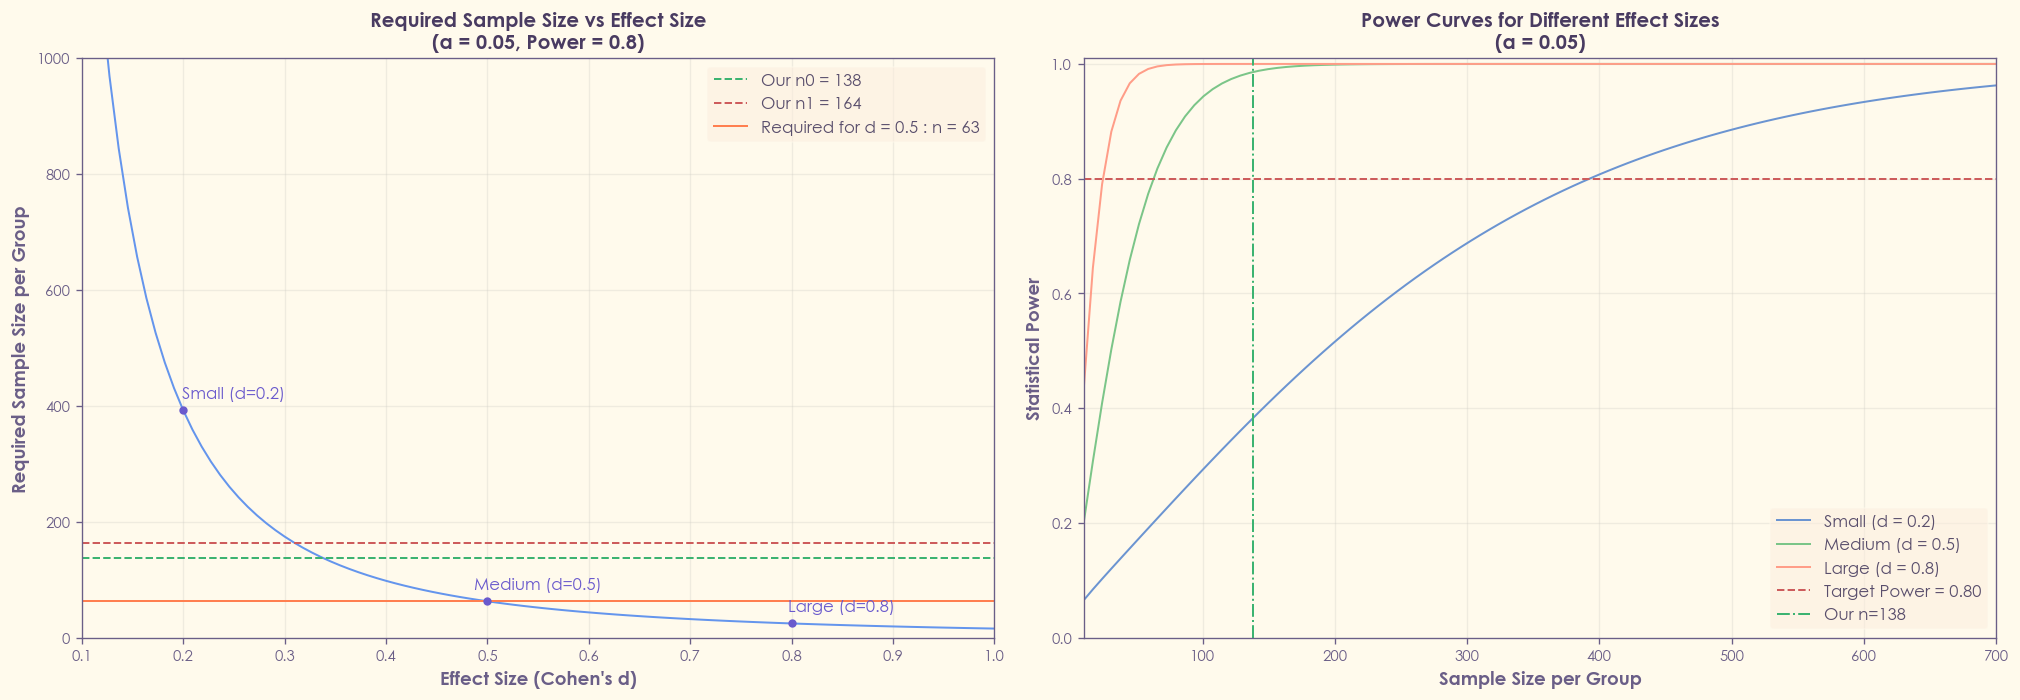

In [11]:
# Visualize Power Analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))

# Plot 1: Required sample size vs effect size
effect_range = np.linspace(0.1, 1.0, 100)
n_range = [2 * ((z_alpha_half + z_beta) / d) ** 2 for d in effect_range]

ax1.plot(effect_range, n_range, linewidth=1.2, color='cornflowerblue')

ax1.axhline(n_no_disease, color='mediumseagreen', linestyle='--', 
            label=f'Our n0 = {n_no_disease}', linewidth=1.2)
ax1.axhline(n_disease, color='indianred', linestyle='--', 
            label=f'Our n1 = {n_disease}', linewidth=1.2)
ax1.axhline(n_required_medium, color='coral', linestyle='-', 
            label=f'Required for d = 0.5 : n = {n_required_medium}', linewidth=1.2)

# Mark standard effect sizes
for effect_name, d in effect_sizes.items():
    n = required_samples[effect_name]
    ax1.plot(d, n, 'o', color='slateblue', markersize=4)
    ax1.annotate(effect_name, (d, n), textcoords="offset pixels", color='slateblue',
                 xytext=(50,12), ha='center', fontsize=10)

ax1.set_xlabel('Effect Size (Cohen\'s d)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Required Sample Size per Group', fontsize=11, fontweight='bold')
ax1.set_title(f'Required Sample Size vs Effect Size\n(α = {alpha}, Power = {power})', 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=10)
ax1.set_xlim(0.1, 1.0)
ax1.set_ylim(0, 1000)

##########################

# Plot 2: Power vs sample size for different effect sizes
n_range_plot = np.linspace(10, 700, 100)
powers_small = [1 - norm.cdf(z_alpha_half - 0.2 * np.sqrt(n/2)) for n in n_range_plot]
powers_medium = [1 - norm.cdf(z_alpha_half - 0.5 * np.sqrt(n/2)) for n in n_range_plot]
powers_large = [1 - norm.cdf(z_alpha_half - 0.8 * np.sqrt(n/2)) for n in n_range_plot]

ax2.plot(n_range_plot, powers_small, label='Small (d = 0.2)', linewidth=1.2)
ax2.plot(n_range_plot, powers_medium, label='Medium (d = 0.5)', linewidth=1.2)
ax2.plot(n_range_plot, powers_large, label='Large (d = 0.8)', linewidth=1.2)
ax2.axhline(0.8, color='indianred', linestyle='--', label='Target Power = 0.80', linewidth=1.2)
ax2.axvline(min(n_no_disease, n_disease), color='mediumseagreen', linestyle='-.', 
            label=f'Our n={min(n_no_disease, n_disease)}', linewidth=1.2)

ax2.set_xlabel('Sample Size per Group', fontsize=11, fontweight='bold')
ax2.set_ylabel('Statistical Power', fontsize=11, fontweight='bold')
ax2.set_title(f'Power Curves for Different Effect Sizes\n(α = {alpha})', 
              fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower right', fontsize=10)
ax2.set_xlim(10, 700)
ax2.set_ylim(0, 1.01)

plt.tight_layout()
#plt.savefig('../contents/figures/sophisticated/power_analysis_actual.eps', bbox_inches='tight')
plt.show()

In [12]:
print("\n" + "="*35)
print("DESCRIPTIVE STATISTICS BY FEATURE")
print("="*35)

descriptive_stats = []

for feature in features:
    group0 = df[df['target'] == 0][feature]
    group1 = df[df['target'] == 1][feature]
    
    descriptive_stats.append({
        'Feature': feature,
        'No_Disease_Mean': group0.mean().round(4),
        'No_Disease_Median': group0.median(),
        'No_Disease_SD': group0.std().round(4),
        'Disease_Mean': group1.mean().round(4),
        'Disease_Median': group1.median(),
        'Disease_SD': group1.std().round(4),
        'Mean_Diff': group1.mean() - group0.mean().round(4),
        'Median_Diff': group1.median() - group0.median(),
        'Variability': (group1.std() - group0.std()).round(4)
    })

desc_df = pd.DataFrame(descriptive_stats)
desc_df


DESCRIPTIVE STATISTICS BY FEATURE


,Feature,No_Disease_Mean,No_Disease_Median,No_Disease_SD,Disease_Mean,Disease_Median,Disease_SD,Mean_Diff,Median_Diff,Variability
0,age,56.6014,58.0,7.9621,52.5854,52.0,9.5120,-4.016034,-6.0,1.5499
1,sex,0.8261,1.0,0.3804,0.5610,1.0,0.4978,-0.265124,0.0,0.1174
2,cp,0.4783,0.0,0.9059,1.3720,2.0,0.9539,0.893651,2.0,0.0480
3,trestbps,134.3986,130.0,18.7299,129.2500,130.0,16.2047,-5.148600,0.0,-2.5252
4,chol,251.0870,249.0,49.4546,242.6402,234.5,53.4566,-8.446756,-14.5,4.0020
5,fbs,0.1594,0.0,0.3674,0.1402,0.0,0.3483,-0.019156,0.0,-0.0191
6,restecg,0.4493,0.0,0.5413,0.5915,1.0,0.5054,0.142163,1.0,-0.0360
7,thalach,139.1014,142.0,22.5988,158.3780,161.0,19.1991,19.276649,19.0,-3.3997
8,exang,0.5507,1.0,0.4992,0.1402,0.0,0.3483,-0.410456,-1.0,-0.1509
9,oldpeak,1.5855,1.4,1.3003,0.5866,0.2,0.7817,-0.998915,-1.2,-0.5186


In [13]:
# Highlight features with large differences
large_diff = desc_df[abs(desc_df['Mean_Diff']) > desc_df['Mean_Diff'].std()]
large_variability = desc_df[abs(desc_df['Variability']) > desc_df['Variability'].std()]

print(f"\nFeatures with large mean differences:")
for _, row in large_diff.iterrows():
    print(f"  {row['Feature']}: Δ = {row['Mean_Diff']:.2f}")
print(f"\nFeatures with large Variability:")
for _, row in large_variability.iterrows():
    print(f"  {row['Feature']}: Δ = {row['Variability']:.2f}")

#desc_df.to_csv('../contents/tables/sophisticated/descriptive_statistics_actual.csv', index=False)


Features with large mean differences:
  chol: Δ = -8.45
  thalach: Δ = 19.28

Features with large Variability:
  trestbps: Δ = -2.53
  chol: Δ = 4.00
  thalach: Δ = -3.40


#### Feature Disparity Analysis (EDA Insights)

This analysis flags features whose separation between the `Target=0` (No Disease) and `Target=1` (Disease) groups is unusually large, relative to the typical variation across all features (Δ > 1 standard deviation of all differences).

Features `chol & thalac` shows the central tendency (mean) of the two groups are far apart, suggesting a major shift in the feature value with disease. Features `trestbps, chol, thalach` shows that the disease status significantly changes the data's spread (standard deviation), indicating inconsistent behavior between groups.

In [14]:
print("\n" + "="*45)
print("NORMALITY TESTING (Shapiro-Wilk Normality Test)")
print("="*45)
print("  Testing if features follow normal distribution")
print("  Required for Pearson correlation; not required for Mann-Whitney/Spearman")
print(" -"*45)

normality_results = []

for feature in features:
    # Overall normality
    stat_all, p_all = shapiro(df[feature])
    
    # By group
    stat_0, p_0 = shapiro(df[df['target']==0][feature])
    stat_1, p_1 = shapiro(df[df['target']==1][feature])
    
    normality_results.append({
        'Feature': feature,
        'Overall_p': p_all,
        'Overall_Normal': 'Yes' if p_all > 0.05 else 'No',
        'Group0_p': p_0,
        'Group0_Normal': 'Yes' if p_0 > 0.05 else 'No',
        'Group1_p': p_1,
        'Group1_Normal': 'Yes' if p_1 > 0.05 else 'No'
    })

normality_df = pd.DataFrame(normality_results)

non_normal_count = (normality_df['Overall_Normal'] == 'No').sum()
print(f"\nNon-normal features: {non_normal_count}/13")

non_normal_features = normality_df[normality_df['Overall_Normal']=='No']['Feature'].tolist()
if non_normal_features:
    print(f"  Non-normal: {', '.join(non_normal_features)}")
else:
    print(f"  All the features are normally distributed!")

#normality_df.to_csv('../contents/tables/sophisticated/normality_tests_actual.csv', index=False)
normality_df


NORMALITY TESTING (Shapiro-Wilk Normality Test)
  Testing if features follow normal distribution
  Required for Pearson correlation; not required for Mann-Whitney/Spearman
 - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

Non-normal features: 13/13
  Non-normal: age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal


,Feature,Overall_p,Overall_Normal,Group0_p,Group0_Normal,Group1_p,Group1_Normal
0,age,6.744821e-03,No,2.867946e-03,No,1.320410e-01,Yes
1,sex,3.124179e-26,No,1.955486e-20,No,1.188050e-18,No
2,cp,1.911408e-19,No,2.431928e-18,No,2.328175e-11,No
3,trestbps,1.419496e-06,No,8.365059e-05,No,1.156095e-02,No
4,chol,5.195915e-09,No,3.791942e-01,Yes,2.877822e-09,No
5,fbs,6.199097e-30,No,9.394939e-21,No,5.605986e-23,No
6,restecg,1.506615e-23,No,5.847343e-16,No,4.247348e-18,No
7,thalach,8.268252e-05,No,4.253970e-01,Yes,5.433098e-04,No
8,exang,4.364069e-26,No,4.580550e-17,No,5.605986e-23,No
9,oldpeak,9.989736e-17,No,3.307980e-06,No,1.033859e-14,No


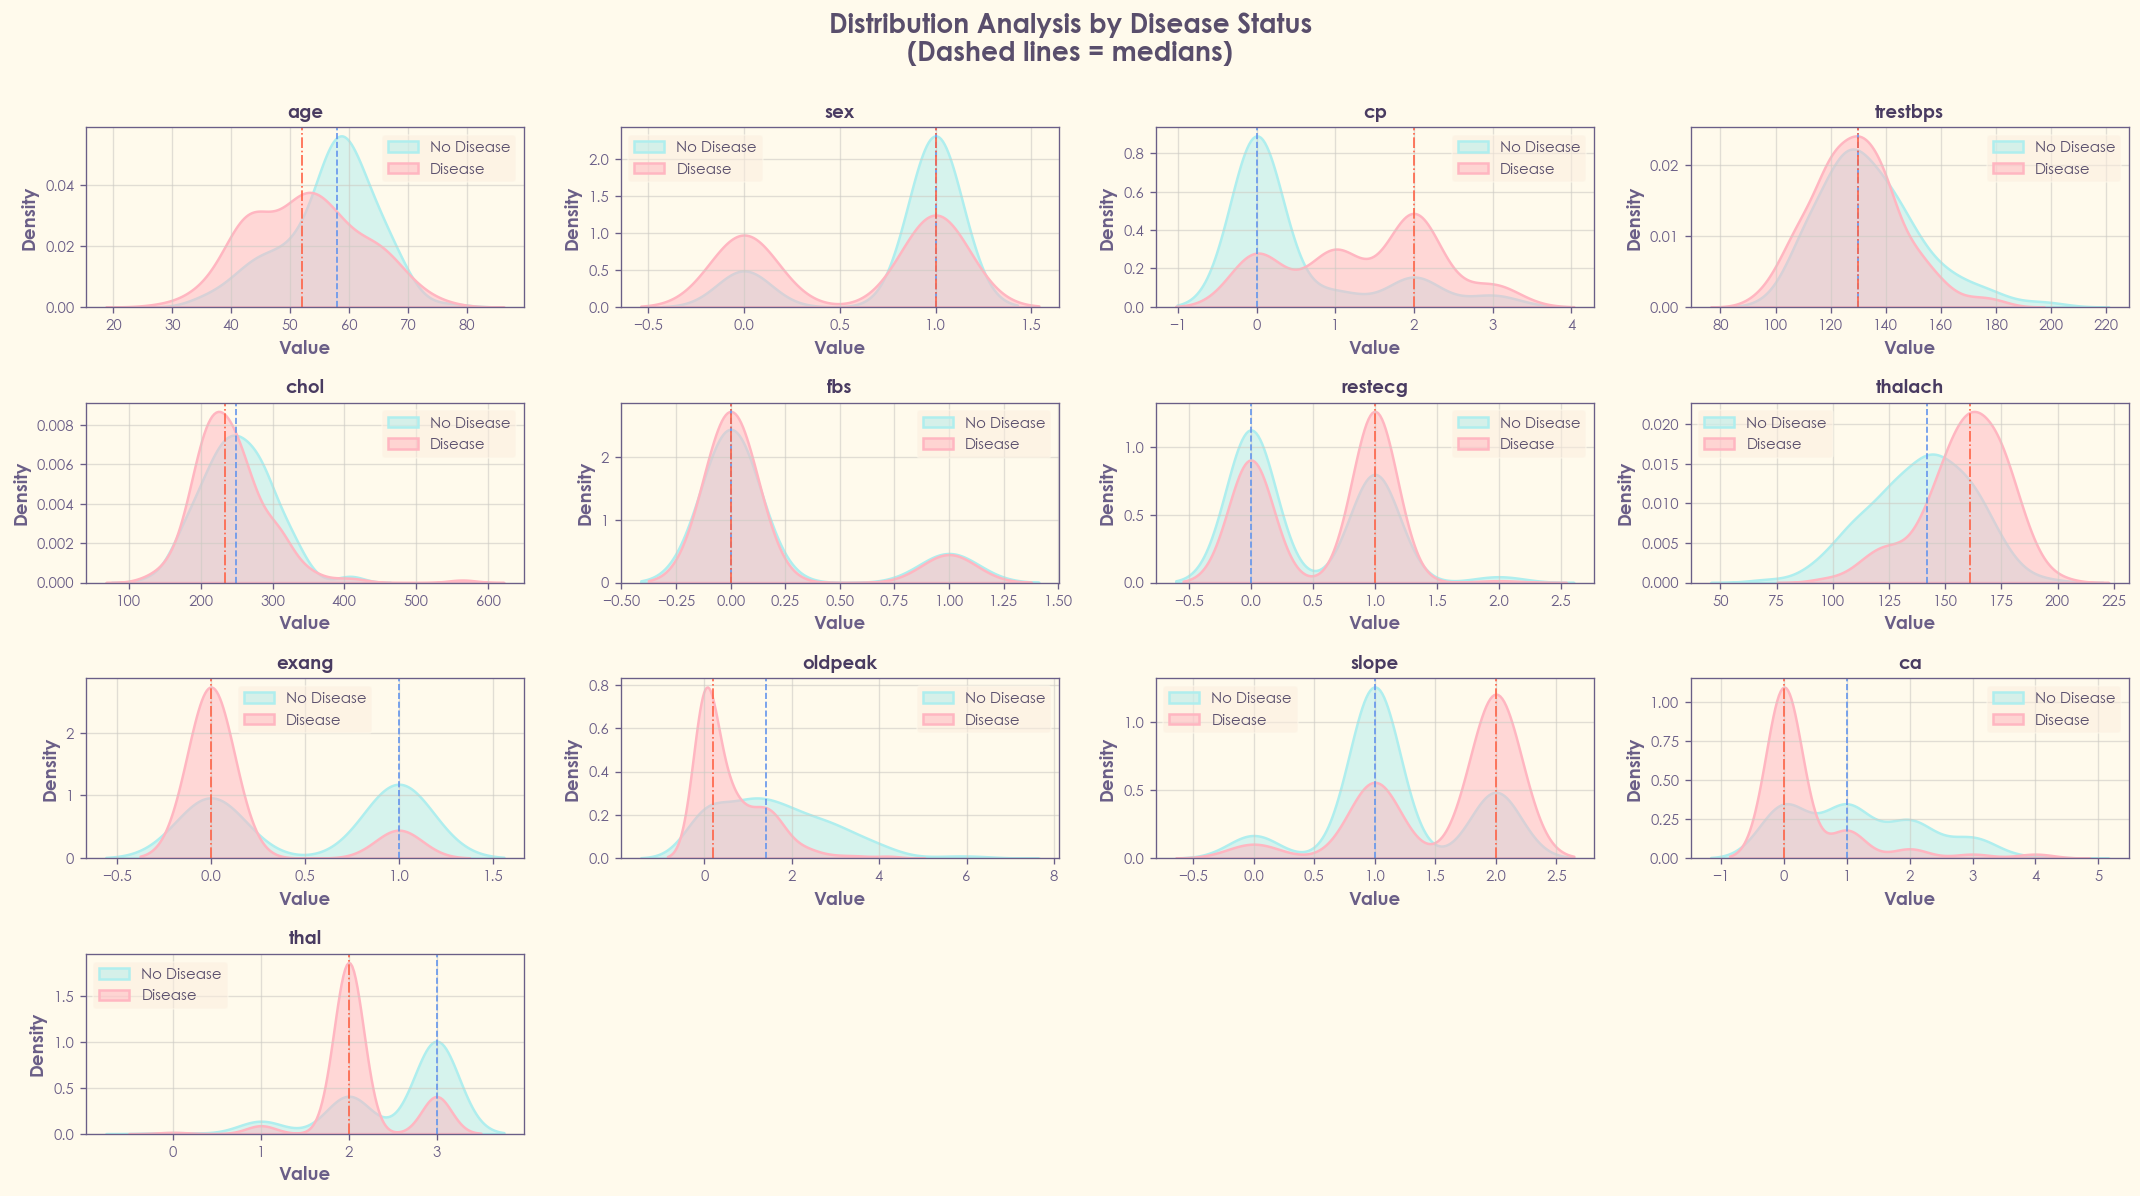

In [15]:
#Distribution visualization of features
fig, axes = plt.subplots(4, 4, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    ax = axes[idx]

    # KDE plots for both groups
    sns.kdeplot(data=df[df['target'] == 0], x=feature, ax=ax,
                label='No Disease', color='paleturquoise', fill=True, alpha=0.5, linewidth=1.5)
    sns.kdeplot(data=df[df['target'] == 1], x=feature, ax=ax,
                label='Disease', color='lightpink', fill=True, alpha=0.5, linewidth=1.5)

    # Add median lines
    med0 = df[df['target'] == 0][feature].median()
    med1 = df[df['target'] == 1][feature].median()
    ax.axvline(med0, color='cornflowerblue', linestyle='--', linewidth=1, alpha=1)
    ax.axvline(med1, color='tomato', linestyle='-.', linewidth=1, alpha=1)

    ax.set_title(f'{feature}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Value', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=9, loc='best')
    ax.grid(alpha=0.6)

# Turn off the last two unused axes
axes[13].axis('off')
axes[14].axis('off')
axes[15].axis('off')

plt.suptitle('Distribution Analysis by Disease Status\n(Dashed lines = medians)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
#plt.savefig('../contents/figures/sophisticated/distributions_by_group_actual.eps', bbox_inches='tight')
plt.show()

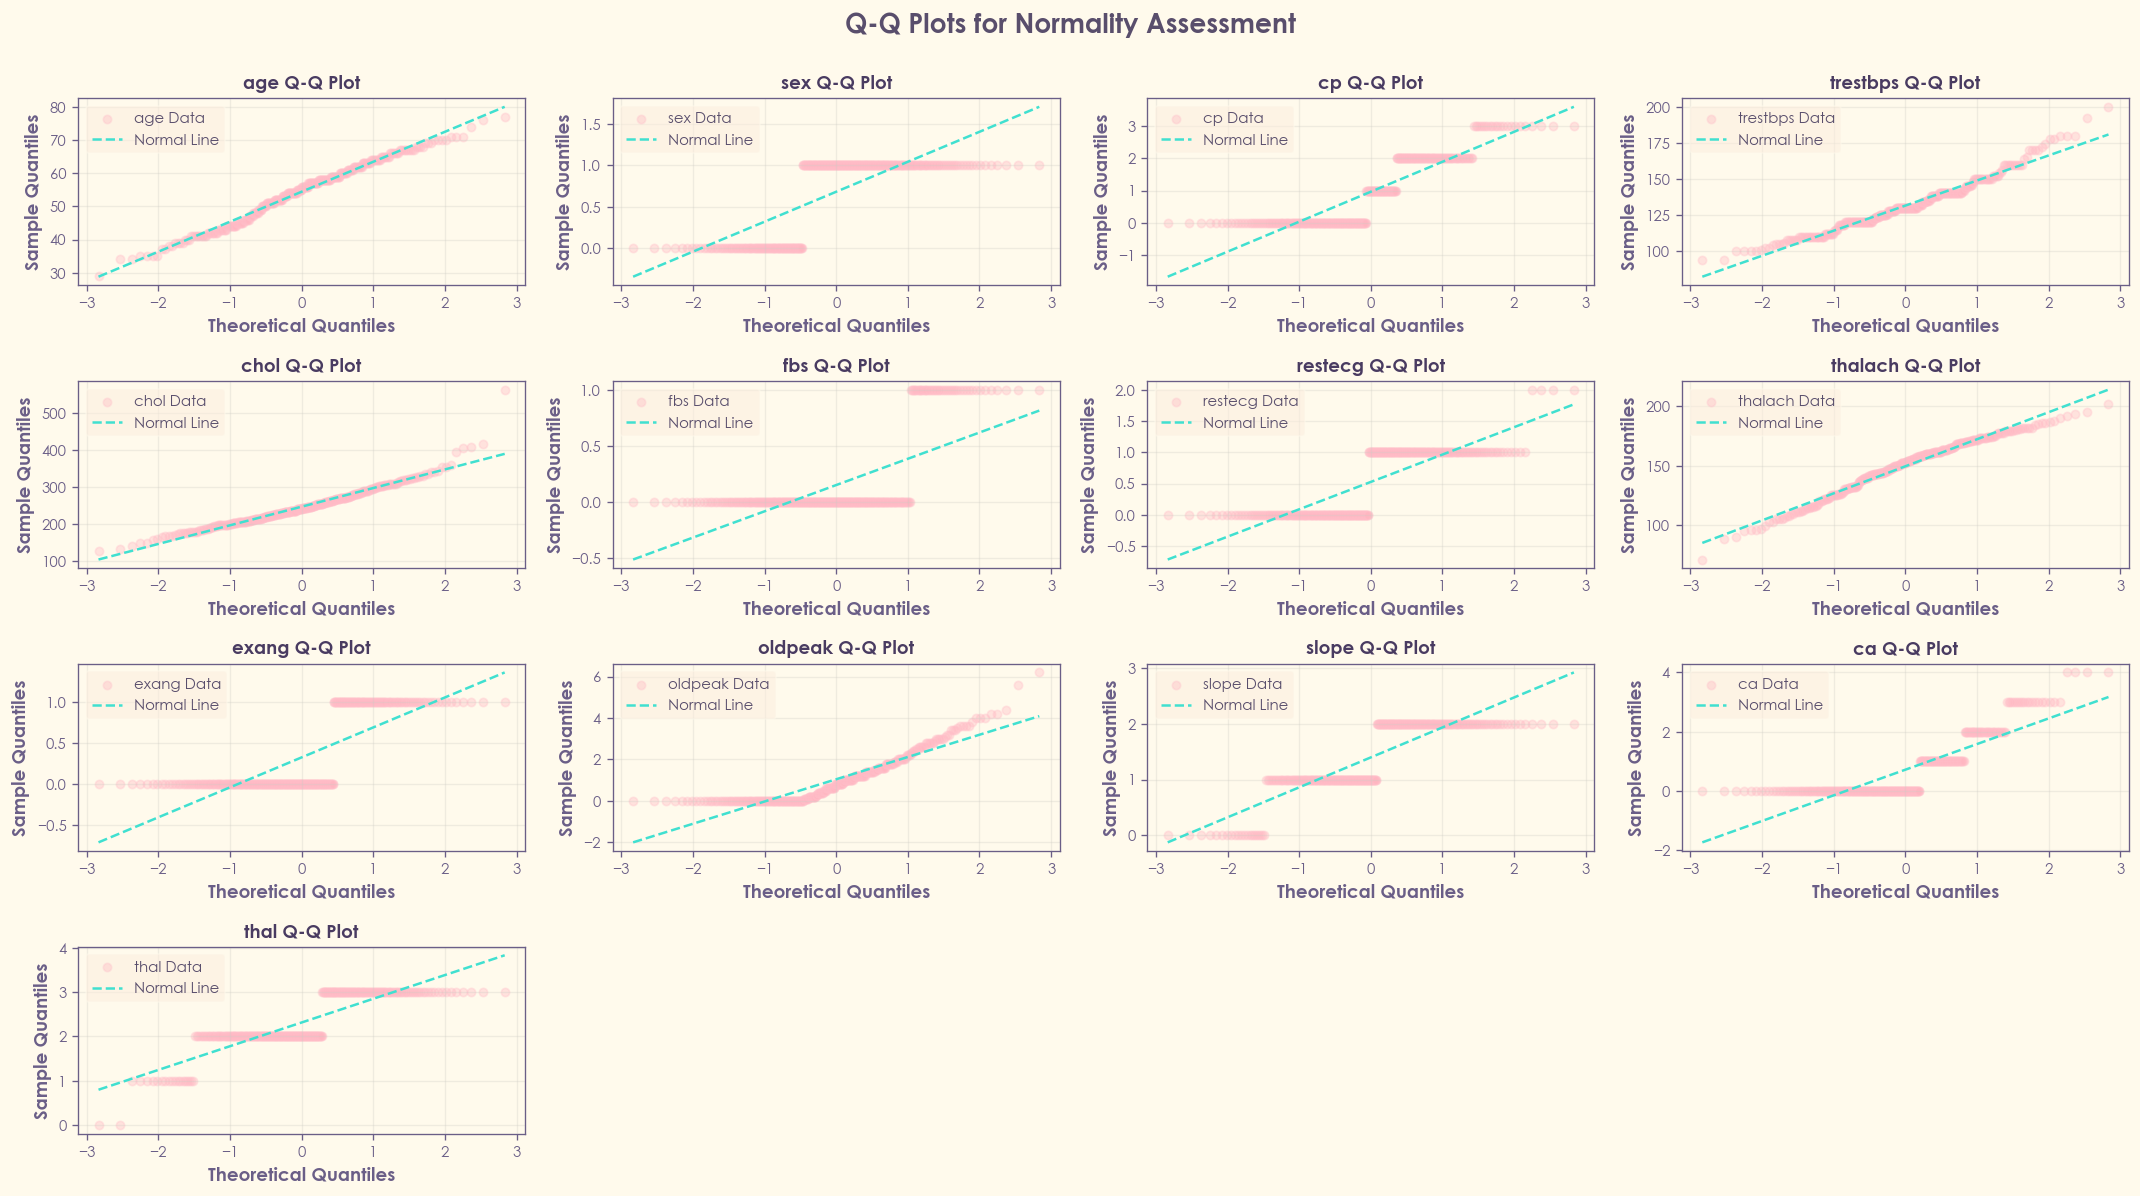

In [16]:
import scipy.stats as stats

fig, axes = plt.subplots(4, 4, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    ax = axes[idx]

    # Get Q-Q data
    (osm, osr), (slope, intercept, r) = stats.probplot(df[feature], dist="norm")

    # Plot points
    ax.scatter(osm, osr, color='lightpink', edgecolor='pink', alpha=0.35, s=25, label=f'{feature} Data')

    # Plot reference line
    ax.plot(osm, slope * osm + intercept, color='turquoise', linestyle='--', linewidth=1.5, label='Normal Line')

    ax.set_title(f'{feature} Q-Q Plot', fontweight='bold', fontsize=11)
    ax.set_xlabel('Theoretical Quantiles', fontsize=11)
    ax.set_ylabel('Sample Quantiles', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Turn off the last two unused axes
axes[13].axis('off')
axes[14].axis('off')
axes[15].axis('off')

plt.suptitle('Q-Q Plots for Normality Assessment', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
#plt.savefig('../contents/figures/sophisticated/qq_plots_actual.eps', bbox_inches='tight')
plt.show()

#### Normality Assumption
The Shapiro-Wilk test and Q-Q plots confirm that **all 13 features are non-normally distributed.**

**Why this matters?**
1. **Pearson Correlation is Invalid**. It measures linear relationships, that relies on the assumption of normality for its test of significance. Its use with this dataset risks the `Type I error` inflation (false positives) and unreliable p-values.
2. So non-parametric tests are required for this dataset. Like, t-test, Mann-Whitney test, and Spearman rank correlation.

In [17]:
print("\n" + "="*25)
print("OUTLIER DETECTION")
print("="*25)

outlier_summary = []

for feature in features:
    data = df[feature]
    
    # IQR method
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_iqr = ((data < lower_bound) | (data > upper_bound)).sum()
    outlier_pct = (outliers_iqr / len(data)) * 100
    
    # Z-score method
    z_scores = np.abs(stats.zscore(data))
    outliers_z = (z_scores > 3).sum()
    
    outlier_summary.append({
        'Feature': feature,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Outliers_IQR': outliers_iqr,
        'Outliers_Zscore': outliers_z,
        'Outlier_Pct': outlier_pct
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df


OUTLIER DETECTION


,Feature,Q1,Q3,IQR,Outliers_IQR,Outliers_Zscore,Outlier_Pct
0,age,48.00,61.00,13.00,0,0,0.000000
1,sex,0.00,1.00,1.00,0,0,0.000000
2,cp,0.00,2.00,2.00,0,0,0.000000
3,trestbps,120.00,140.00,20.00,9,2,2.980132
4,chol,211.00,274.75,63.75,5,4,1.655629
5,fbs,0.00,0.00,0.00,45,0,14.900662
6,restecg,0.00,1.00,1.00,0,0,0.000000
7,thalach,133.25,166.00,32.75,1,1,0.331126
8,exang,0.00,1.00,1.00,0,0,0.000000
9,oldpeak,0.00,1.60,1.60,5,2,1.655629


In [18]:
features_with_outliers = outlier_df[outlier_df['Outliers_IQR'] > 0]['Feature'].tolist()
print(f"\nFeatures with outliers ({len(features_with_outliers)}/13): {', '.join(features_with_outliers)}")

#outlier_df.to_csv('../contents/tables/sophisticated/outlier_analysis_actual.csv', index=False)


Features with outliers (7/13): trestbps, chol, fbs, thalach, oldpeak, ca, thal


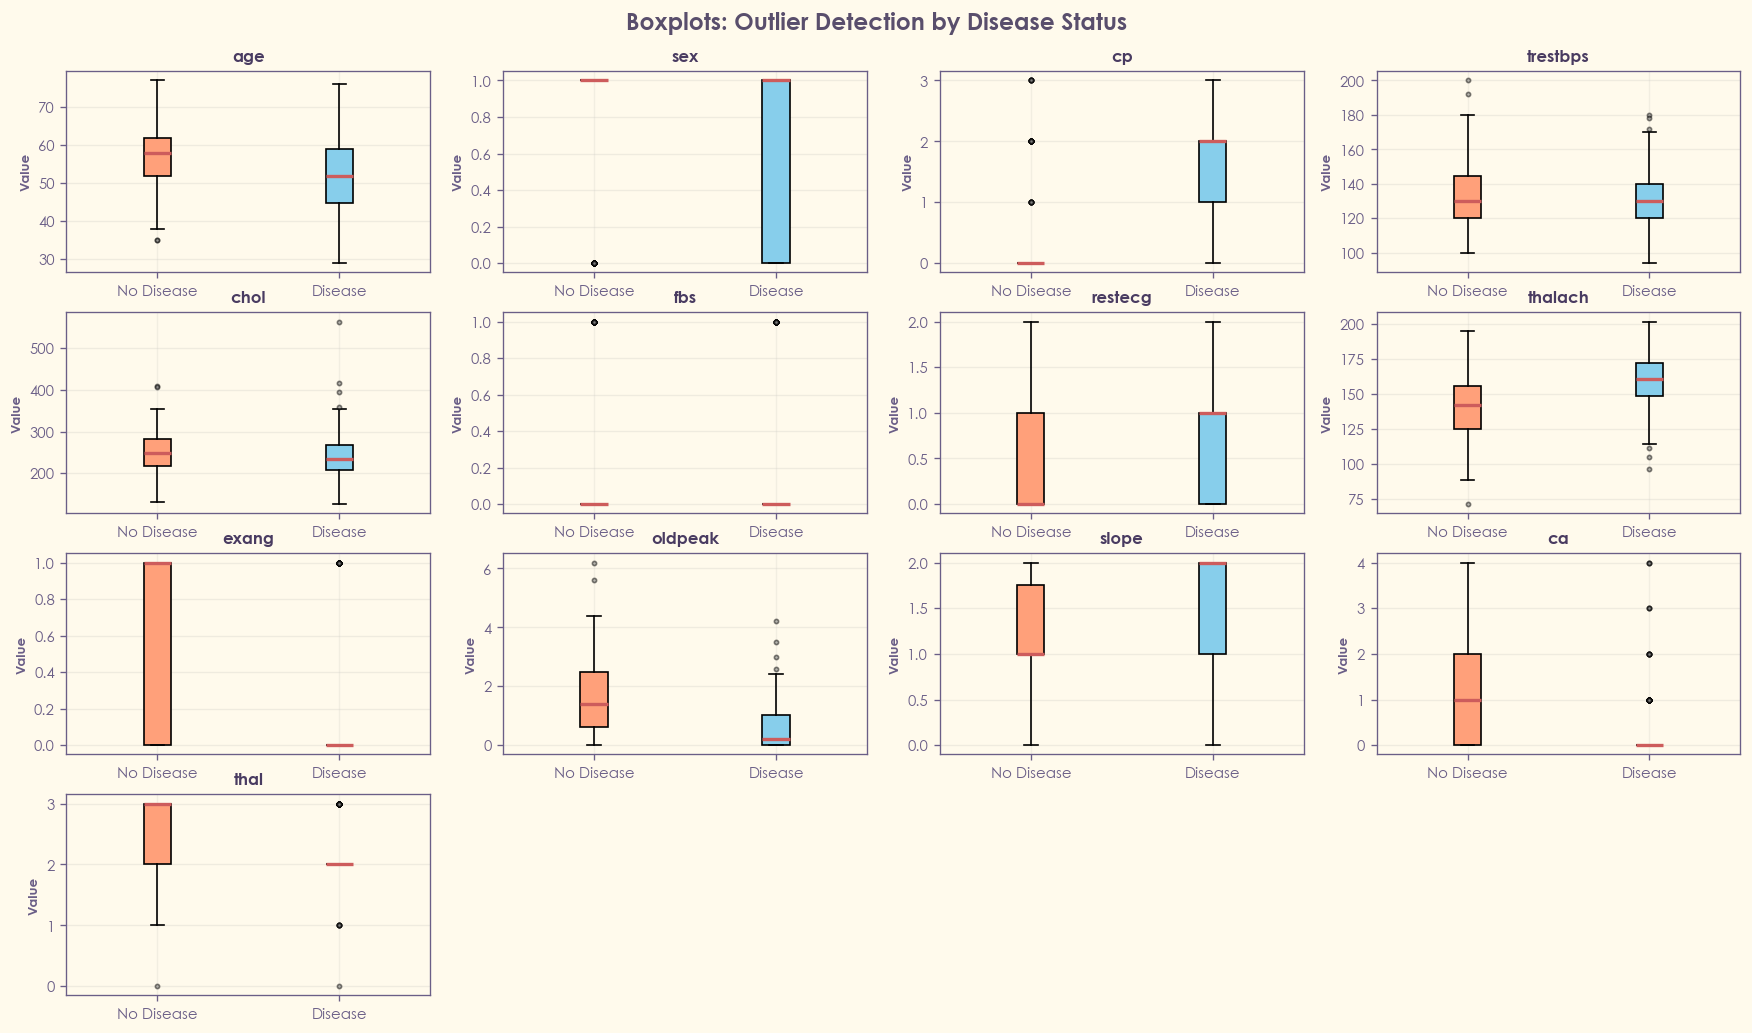

In [19]:
#outlier detection using boxplots
fig, axes = plt.subplots(4, 4, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    ax = axes[idx]
    data_list = [df[df['target'] == 0][feature], df[df['target'] == 1][feature]]
    bp = ax.boxplot(data_list, labels=['No Disease', 'Disease'], patch_artist=True,
                    medianprops=dict(color='indianred', alpha=1, linewidth=2),
                    boxprops=dict(linewidth=1),
                    whiskerprops=dict(linewidth=1),
                    capprops=dict(linewidth=1),
                    flierprops=dict(marker='.', markersize=5, alpha=0.5, markerfacecolor='gray'))

    bp['boxes'][0].set_facecolor('lightsalmon')  # No Disease
    bp['boxes'][1].set_facecolor('skyblue')      # Disease

    ax.set_title(f'{feature}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Value', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# Turn off the last unused subplot
axes[13].axis('off')
axes[14].axis('off')
axes[15].axis('off')

plt.suptitle('Boxplots: Outlier Detection by Disease Status', 
             fontsize=14, fontweight='bold', y=0.93)
#plt.savefig('../contents/figures/sophisticated/boxplots_outliers_actual.eps', bbox_inches='tight')
plt.show()


MULTICOLLINEARITY ANALYSIS
Checking if features are highly correlated with each other.
High multicollinearity can inflate ML feature importance
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 


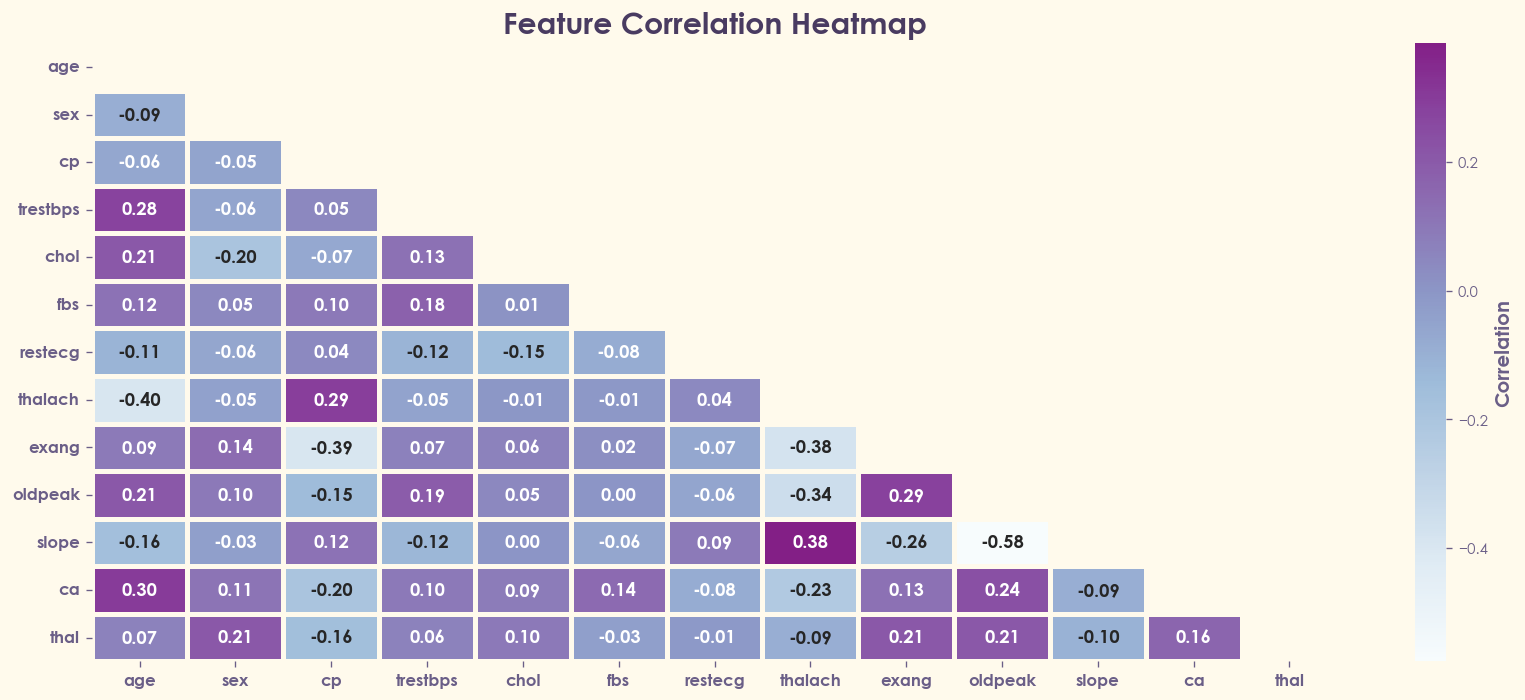

In [20]:
print("\n" + "="*45)
print("MULTICOLLINEARITY ANALYSIS")
print("="*45)
print("Checking if features are highly correlated with each other.\nHigh multicollinearity can inflate ML feature importance")
print("- "*45)

# Compute correlation matrix
corr_matrix = df[features].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot
plt.figure(figsize=(14, 6))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='BuPu',
            center=0, square=False,
            linewidths=3, linecolor='#fffaec',
            annot_kws={"size": 11, "weight": "bold"},
            cbar_kws={"shrink": 1, "label": "Correlation"})

plt.title('Feature Correlation Heatmap', fontsize=18, fontweight='bold')
plt.grid(False)
plt.xticks(rotation=0, fontsize=10, fontweight='bold')
plt.yticks(rotation=0, fontsize=10, fontweight='bold')
plt.tight_layout()
#plt.savefig('../contents/figures/sophisticated/correlation_matrix_actual.eps', bbox_inches='tight')
plt.show()

In [21]:
#findf high correlations
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Feature1': corr_matrix.columns[i],
                'Feature2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

print(f"High Correlation Pairs: {len(high_corr_pairs)}")
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print("\n High correlations detected (|r| > 0.7):")
    print(high_corr_df.to_string(index=False))
else:
    print("No severe multi co-llinearity (all |r| < 0.7)")

High Correlation Pairs: 0
No severe multi co-llinearity (all |r| < 0.7)


**VIF - Variance Inflation Factor:** 
A statistical tool used to detect multicollinearity, or when independent variables in a regression model are highly correlated with each other.

In [22]:
# VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = features
vif_data["VIF"] = [variance_inflation_factor(df[features].values, i) for i in range(len(features))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\nVariance Inflation Factor (VIF):")
print("\tVIF < 5: Low multicollinearity ")
print("\t5-10: Moderate ")
print("\tVIF > 10: High multicollinearity")
print("-"*45)

high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f"\nHigh VIF features:")
else:
    print("\nAll features have acceptable VIF (<10)")

vif_data


Variance Inflation Factor (VIF):
	VIF < 5: Low multicollinearity 
	5-10: Moderate 
	VIF > 10: High multicollinearity
---------------------------------------------

High VIF features:


,Feature,VIF
3,trestbps,58.776923
7,thalach,42.631809
0,age,39.567644
4,chol,26.281421
12,thal,17.141073
10,slope,10.015857
1,sex,3.507112
9,oldpeak,3.071361
2,cp,2.409980
6,restecg,2.051037


In [23]:
#vif_data.to_csv('../contents/tables/sophisticated/vif_multicollinearity_actual.csv', index=False)

#### Feature Collinearity and Variance Assessment
The correlation heatmap provides the pairwise correlation coefficient, r for every feature combination. It confirmed no severe pairwise multicollinearity (all absolute correlations were less than 0.7). This suggests that, individually, no two features are measuring the exact same information.

The analysis identified critical multicollinearity in several features (`e.g., trestbps, thalach, age, chol, thal`), with VIF values significantly exceeding the threshold of 10. Although the high VIF does not impact the current feature significance tests (Mann-Whitney U-test), it is a major flag for future modeling. If a linear model (like Logistic Regression) is used, these features will lead to highly unstable coefficient estimates and reduced model interpretability.

## Doing STATS Correctly
1. Assumption Validations: Mann-Whitney U tests, Chi-square tests, and Correlation Assumption Validation
2. Multiple Correction Tests: Bondferroni correction
3. Calculate Effect Sizes (MISSING IN ORIGINAL)
4. Calculate Confidence Intervals (MISSING IN ORIGINAL)

### 4.1 Mann-Whitney U-test Assumption Validation

```
Mann-Whitney U Test Assumptions:
    1. Independence of observations (patients are unique)
    2. Ordinal or continuous dependent variable (all features qualify)
    3. Distribution shapes between groups

INTERPRETATION DEPENDS ON DISTRIBUTION SHAPES:
    - If shapes are SIMILAR --> Mann-Whitney tests for MEDIAN differences
    - If shapes DIFFER --> Mann-Whitney tests for STOCHASTIC DOMINANCE (one group tends to have higher values)
```

###### Hypotheses for Mann-Whitney U-Test (Group Comparison):
- $H_0^{(Null Hypothesis)}$: The distribution of the feature being tested is identical for patients with heart disease (`Target=1`) and patients without heart disease (`Target=0`).
- $H_1^{(Alternative Hypothesis)}$: The distribution of the feature being tested is significantly different between the patients with heart disease and those without.

*Note: This test is most appropriate for features like `age, trestbps, chol, thalach, oldpeak, ca, and thal` to compare their central tendency and spread between the groups.*


In [24]:
# Load naive reproduction results of the original paper
table2_naive = pd.read_csv('../contents/tables/reproduced/table2_reproduced_actual.csv')

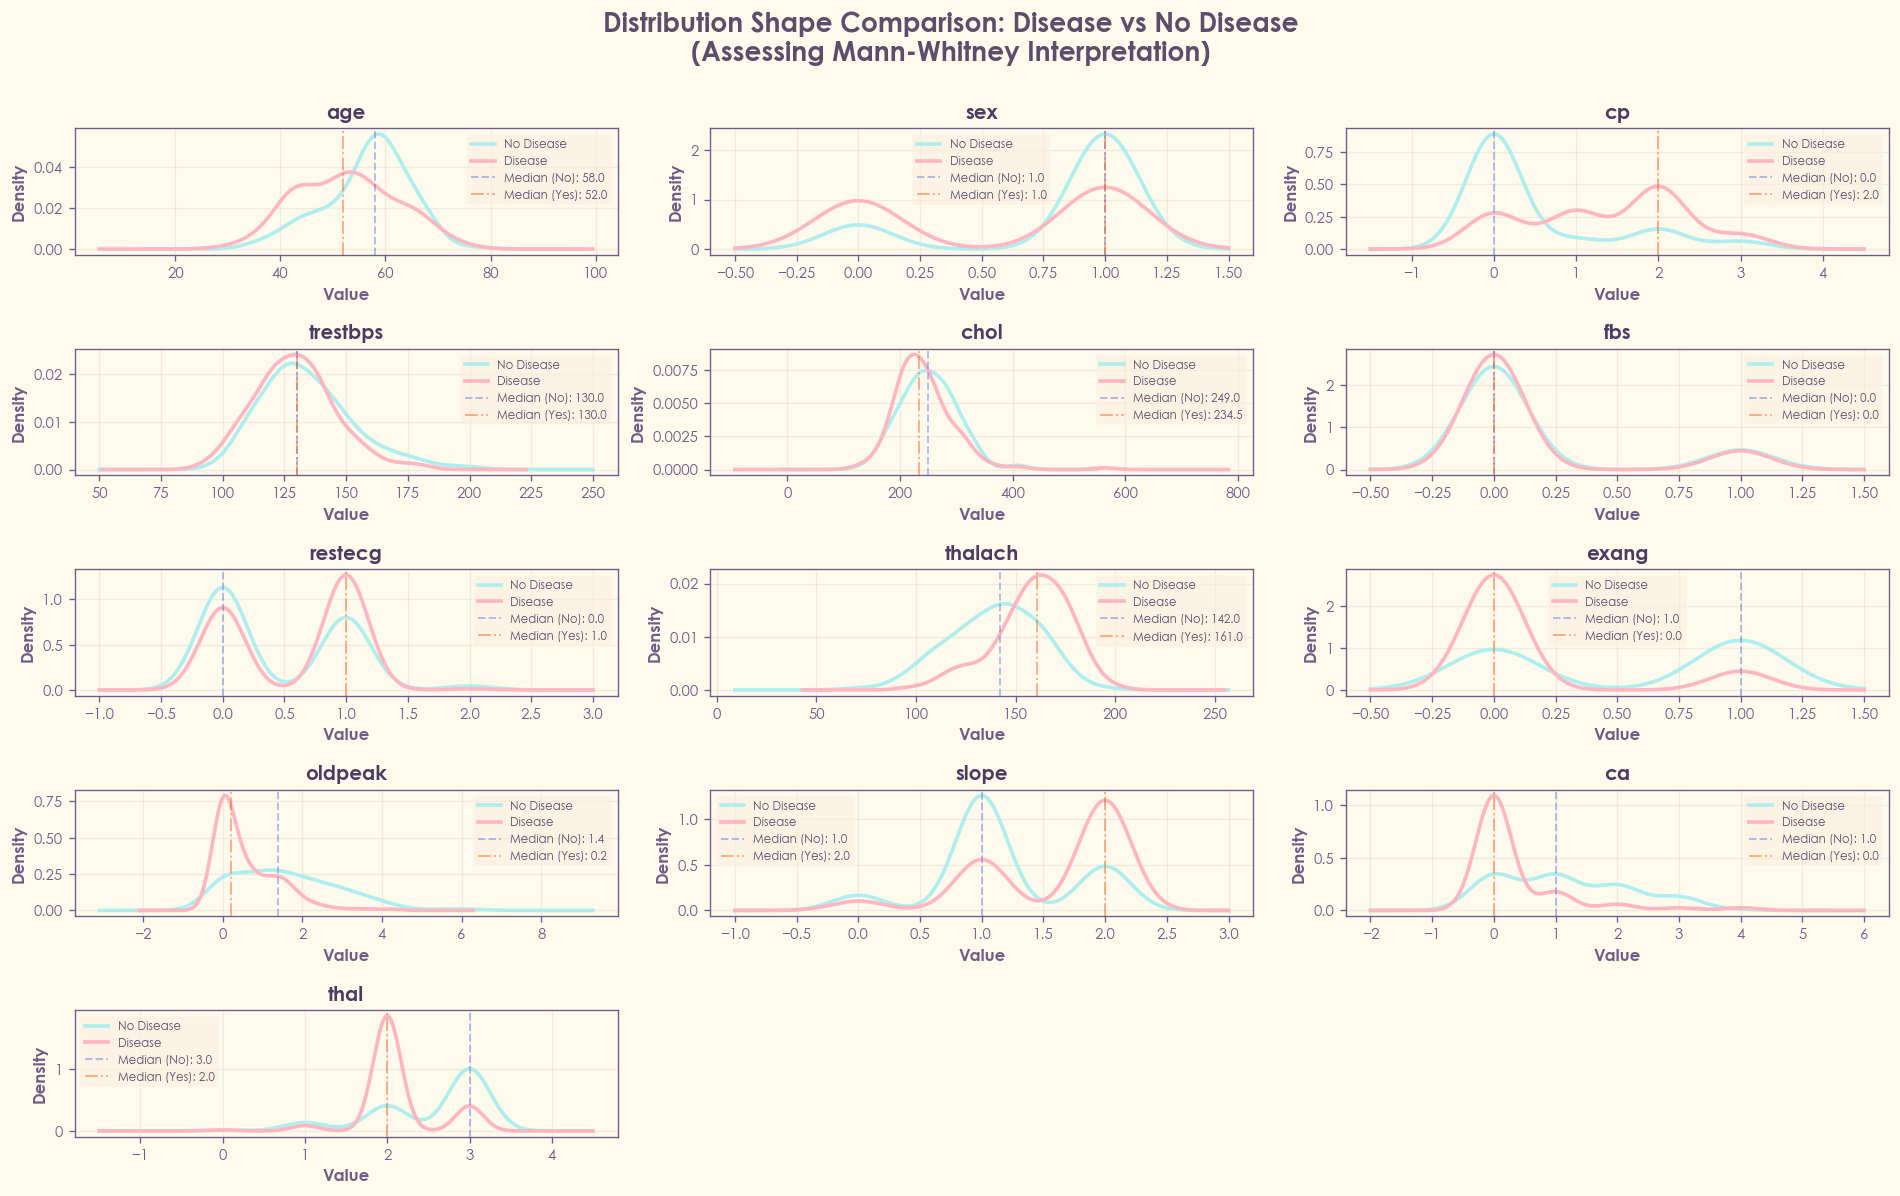

In [25]:
## Assessing Visual distriibution shape similarrity
shape_assessment = []

fig, axes = plt.subplots(5, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    ax = axes[idx]
    
    group0 = df[df['target'] == 0][feature]
    group1 = df[df['target'] == 1][feature]
    
    # Kernel Density Estimation (KDE) for smoothed histogram
    group0.plot.kde(ax=ax, label='No Disease', linewidth=2.2, color='paleturquoise')
    group1.plot.kde(ax=ax, label='Disease', linewidth=2.2, color='lightpink')
    
    # Add medians
    med0, med1 = group0.median(), group1.median()
    ax.axvline(med0, color='royalblue', linestyle='--', linewidth=1.2, alpha=0.4, label=f'Median (No): {med0:.1f}')
    ax.axvline(med1, color='orangered', linestyle='-.', linewidth=1.2, alpha=0.4, label=f'Median (Yes): {med1:.1f}')
    
    ax.set_title(f'{feature}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Value', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=7, loc='best')
    ax.grid(alpha=0.3)
    
    # Assess shape similarity wiuth Simple heuristic: compare skewness
    skew0 = group0.skew()
    skew1 = group1.skew()
    skew_diff = abs(skew0 - skew1)
    
    # Assess if shapes are similar
    similar_shape = skew_diff < 0.5
    
    shape_assessment.append({
        'Feature': feature,
        'Skewness_No_Disease': skew0,
        'Skewness_Disease': skew1,
        'Skewness_Difference': skew_diff,
        'Similar_Shape': 'Yes' if similar_shape else 'No',
        'Median_No_Disease': med0,
        'Median_Disease': med1,
        'Median_Difference': med1 - med0
    })

# Remove extra subplots
for idx in range(len(features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribution Shape Comparison: Disease vs No Disease\n(Assessing Mann-Whitney Interpretation)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
#plt.savefig('../contents/figures/sophisticated/distribution_shapes_mann_whitney_actual.eps', bbox_inches='tight')
plt.show()

In [26]:
## Assessing Quantitative Shape Similarity

shape_df = pd.DataFrame(shape_assessment)
print("\nSkewness Comparison:")
print(shape_df[['Feature', 'Skewness_No_Disease', 'Skewness_Disease', 
               'Skewness_Difference', 'Similar_Shape']].to_string(index=False))

similar_count = (shape_df['Similar_Shape'] == 'Yes').sum()
similar_shapes = shape_df[shape_df['Similar_Shape'] == 'Yes']['Feature'].tolist()

print(f"\nFeatures counts similar distribution shapes: {similar_count}/13")
print(f"Features with Similar shapes: {', '.join(similar_shapes)}\n")

dissimilar_features = shape_df[shape_df['Similar_Shape'] == 'No']['Feature'].tolist()
dissimilar_count = (shape_df['Similar_Shape'] == 'No').sum()
if dissimilar_features:
    print(f"Features counts different shapes: {dissimilar_count}/13")
    print(f"Features with different shapes: {', '.join(dissimilar_features)}")

print("\n======MEDIAN DIFFERENCES======")
print(shape_df[['Feature', 'Median_No_Disease', 'Median_Disease', 'Median_Difference']].round(4).to_string(index=False))


Skewness Comparison:
 Feature  Skewness_No_Disease  Skewness_Disease  Skewness_Difference Similar_Shape
     age            -0.548502          0.116956             0.665458            No
     sex            -1.739584         -0.248011             1.491573            No
      cp             1.649560         -0.121167             1.770727            No
trestbps             0.858872          0.433387             0.425486           Yes
    chol             0.316402          1.755008             1.438606            No
     fbs             1.881258          2.091266             0.210008           Yes
 restecg             0.624617         -0.230880             0.855497            No
 thalach            -0.296783         -0.698025             0.401242           Yes
   exang            -0.206199          2.091266             2.297465            No
 oldpeak             0.741389          1.638980             0.897592            No
   slope             0.032571         -1.157779             1.190

In [27]:
# Identify large median differences
large_diff_threshold = shape_df['Median_Difference'].abs().std()
large_diff = shape_df[shape_df['Median_Difference'].abs() > large_diff_threshold]

print(f"Features with large median differences (|Δ| > {large_diff_threshold:.2f}):")
for _, row in large_diff.iterrows():
    direction = "higher" if row['Median_Difference'] > 0 else "lower"
    print(f"\t{row['Feature']}: {direction} in disease group (Δ = {row['Median_Difference']:.2f})")

# Save
#shape_df.to_csv('../contents/tables/sophisticated/mann_whitney_shape_assessment_actual.csv', index=False)

Features with large median differences (|Δ| > 6.07):
	chol: lower in disease group (Δ = -14.50)
	thalach: higher in disease group (Δ = 19.00)


#### **The Critical Question About Mann-Whitney U Test**

While visual inspection of distribution shapes and skewness comparison provide intuitive understanding, we need a **formal statistical test** to rigorously assess whether the distributions of the two groups (disease vs. no disease) have the same shape. The interpretation of Mann-Whitney U test results **depends critically on distribution shapes**. Key Findings from Distribution Shapes are:

1. **Large Median Shifts (|Δ| > 1):**
```
thalach:  +19.0 (Disease group has much higher max heart rate)
chol:     -14.5 (Disease group has lower cholesterol - unexpected!)  <---------|
age:      -6.0  (Disease group is younger - unexpected!)             <---------|
cp:       +2.0  (Disease group has more severe chest pain)
oldpeak:  -1.2  (Disease group has less ST depression)
```

2. **No or Minimal Median Difference (|Δ| ≤ 0.5):**
```
trestbps:  0.0  (Blood pressure medians identical!)
fbs:       0.0  (Fasting blood sugar medians identical!)
sex:       0.0  (Gender distribution identical!)
```

3. The negative median differences for age and cholesterol are **counterintuitive** - I'd expect diseased patients to be older and have higher cholesterol. This suggests:
    - The "disease" label may include different stages or types
    - The dataset may have sampling bias
    - Other factors (like thalach, cp) are stronger predictors
    
##### **What's next?**

The plots show some features with similar medians despite shape difference and vice versa. Now, to formally determine **statistical significance despite the shape difference**, I will be utilizing the **Kolmogorov-Smirnov Test** [3,4,5]. So that I could answer,
 - Are the observed shape differences statistically significant?
 - Whhich interpretation framework should we use for Mann-Whitney results?
 - Can we trust median comparisons, or we must use stochastic dominance interpretation?

In [28]:
print("K-S Test Hypothesis: If two distributions are identical or not")
print("\tH0: Distributions have same shape")
print("\tH1: Distributions differ in shape")

K-S Test Hypothesis: If two distributions are identical or not
	H0: Distributions have same shape
	H1: Distributions differ in shape


In [29]:
print("\n" + "-"*55)
print("KOLMOGOROV-SMIRNOV TEST (Distribution Shape Equality)")
print("-"*55)

from scipy.stats import ks_2samp

ks_results = []

for feature in features:
    group0 = df[df['target'] == 0][feature]
    group1 = df[df['target'] == 1][feature]
    
    ks_stat, ks_p = ks_2samp(group0, group1)
    
    ks_results.append({
        'Feature': feature,
        'KS_Statistic': ks_stat,
        'KS_p_value': ks_p,
        'Same_Distribution': 'No' if ks_p < 0.05 else 'Yes'
    })

ks_df = pd.DataFrame(ks_results)
ks_df


-------------------------------------------------------
KOLMOGOROV-SMIRNOV TEST (Distribution Shape Equality)
-------------------------------------------------------


,Feature,KS_Statistic,KS_p_value,Same_Distribution
0,age,0.284818,7.180525e-06,No
1,sex,0.265111,3.825218e-05,No
2,cp,0.515818,9.626658e-19,No
3,trestbps,0.115765,2.425372e-01,Yes
4,chol,0.153234,5.169837e-02,Yes
5,fbs,0.019176,1.000000e+00,Yes
6,restecg,0.157830,4.151954e-02,No
7,thalach,0.413220,5.349757e-12,No
8,exang,0.410481,7.606229e-12,No
9,oldpeak,0.401467,2.461885e-11,No


In [30]:
same_dist = (ks_df['Same_Distribution'] == 'Yes').sum()
same_dist_features = ks_df[ks_df['Same_Distribution'] == 'Yes']['Feature'].tolist()

print(f"Number of Features with similar distrribution: {same_dist}")
print(f"Features: {', '.join(same_dist_features)}")

#ks_df.to_csv('../contents/tables/sophisticated/kolmogorov_smirnov_tests_actual.csv', index=False)

Number of Features with similar distrribution: 3
Features: trestbps, chol, fbs


**10 out of 13 features show significantly different distributions (p < 0.05)**. Only **fbs, chol, and trestbps** shows no significant distributional difference (p_fbs=1.0, p_chol=0.051, and p_trestbps=0.242). Although the paper only stated that `fbs` is not associated with heart disease, but K-S test suggests `chol` and `trestbps` are also might not be associated. This was UNEXPECTED!

**CONCLUSION:**
   - Mann-Whitney U test is APPROPRIATE (doesn't require identical distributions)
   - Interpretation: Tests if one group TENDS to have higher values
   
 #### Final Assumption about Mann-Whitney U test
 - ASSUMPTION 1: Independence of Observations is satistfied as each patient is a unique observation.
 - ASSUMPTION 2: Ordinal or Continuous Data, which it is
 - ASSUMPTION 3: Similar Sample Sizes (for power) are satisfied. n0=499, n1=526 (well-balanced, ratio=0.95)
 - ASSUMPTION 4: Distribution Shapes differ between groups (confirmed from K-S Test)
 
 Therefore,
 ##### Mann-Whitney U test is APPROPRIATE and VALID for this data

#### An Extra Observation to the Mann-Whitney U tests

Mann-Whitney U test is a non-parametric test and it is specifically designed for situations where the data does not follow a standard normal distribution. The fact that **the KS test highlights the differences and confirms that it is not plausible to use a parametric test (like the the Pearson Test or, T-test)**. Therefore, MWU is the correct alternative.

### 4.2 Chi-square Test Assumption Validation

###### Hypotheses for Chi-Square Test (Association/Independence):
- $H_0^{(Null Hypothesis)}$: There is no statistically significant association between the feature being tested (`e.g., sex, age`) and the presence of heart disease (`Target=1`). The variables are independent.
- $H_1^{(Alternative Hypothesis)}$: There is a statistically significant association between the feature being tested and the presence of heart disease. The variables are dependent.

*Note: This is the appropriate test for purely discrete/categorical features like `sex, cp, fbs, restecg, exang, and slope`.*

In [31]:
print("EXPECTED FREQUENCY VALIDATION")
print("-"*30)

chi_square_validation = []

for feature in features:
    # Create contingency table
    contingency = pd.crosstab(df[feature], df['target'])
    
    # Perform chi-sqr to get expected frequencies
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    # Calculate cells with low expected frequencies
    total_cells = expected.size
    cells_below_5 = (expected < 5).sum()
    cells_below_1 = (expected < 1).sum()
    pct_below_5 = (cells_below_5 / total_cells) * 100
    
    # Check if assumptions met
    assumption_met = (pct_below_5 <= 20) and (cells_below_1 == 0)
    
    chi_square_validation.append({
        'Feature': feature,
        'Total_Cells': total_cells,
        'Cells_Below_5': cells_below_5,
        'Cells_Below_1': cells_below_1,
        'Pct_Below_5': pct_below_5,
        'Assumption_Met': 'Yes' if assumption_met else 'No',
        'Chi2_Statistic': chi2,
        'p_value': p,
        'df': dof,
        'Min_Expected': expected.min()
    })

chi_val_df = pd.DataFrame(chi_square_validation)

print("\nExpected Frequency Assessment:")
print(chi_val_df[['Feature', 'Total_Cells', 'Cells_Below_5', 'Pct_Below_5', 'Min_Expected', 'Assumption_Met']].round(2).to_string(index=False))

EXPECTED FREQUENCY VALIDATION
------------------------------

Expected Frequency Assessment:
 Feature  Total_Cells  Cells_Below_5  Pct_Below_5  Min_Expected Assumption_Met
     age           82             60        73.17          0.46             No
     sex            4              0         0.00         43.87            Yes
      cp            8              0         0.00         10.51            Yes
trestbps           98             80        81.63          0.46             No
    chol          304            304       100.00          0.46             No
     fbs            4              0         0.00         20.56            Yes
 restecg            6              2        33.33          1.83             No
 thalach          182            180        98.90          0.46             No
   exang            4              0         0.00         45.24            Yes
 oldpeak           80             63        78.75          0.46             No
   slope            6              0  

In [32]:
print("ASSUMPTION VIOLATION ANALYSIS")
print("-"*50)

valid_features = chi_val_df[chi_val_df['Assumption_Met'] == 'Yes']['Feature'].tolist()
invalid_features = chi_val_df[chi_val_df['Assumption_Met'] == 'No']['Feature'].tolist()

print(f"Features with valid Chi-square ({len(valid_features)}/13):")
print("   "+", ".join(valid_features))

if invalid_features:
    print(f"\nFeatures violating assumptions ({len(invalid_features)}/13):")
    for feat in invalid_features:
        row = chi_val_df[chi_val_df['Feature'] == feat].iloc[0]
        print(f"  {feat:<10} : {row['Pct_Below_5']:.1f}% cells < 5 (min expected: {row['Min_Expected']:.2f})")
else:
    print(f"\n ALL features meet Chi-square assumptions!")
    
# Save validation results
#chi_val_df.to_csv('../contents/tables/sophisticated/chi_square_assumption_validation_actual.csv', index=False)

ASSUMPTION VIOLATION ANALYSIS
--------------------------------------------------
Features with valid Chi-square (6/13):
   sex, cp, fbs, exang, slope, ca

Features violating assumptions (7/13):
  age        : 73.2% cells < 5 (min expected: 0.46)
  trestbps   : 81.6% cells < 5 (min expected: 0.46)
  chol       : 100.0% cells < 5 (min expected: 0.46)
  restecg    : 33.3% cells < 5 (min expected: 1.83)
  thalach    : 98.9% cells < 5 (min expected: 0.46)
  oldpeak    : 78.8% cells < 5 (min expected: 0.46)
  thal       : 25.0% cells < 5 (min expected: 0.91)


VISUALIZING EXPECTED FREQUENCIES
-----------------------------------


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


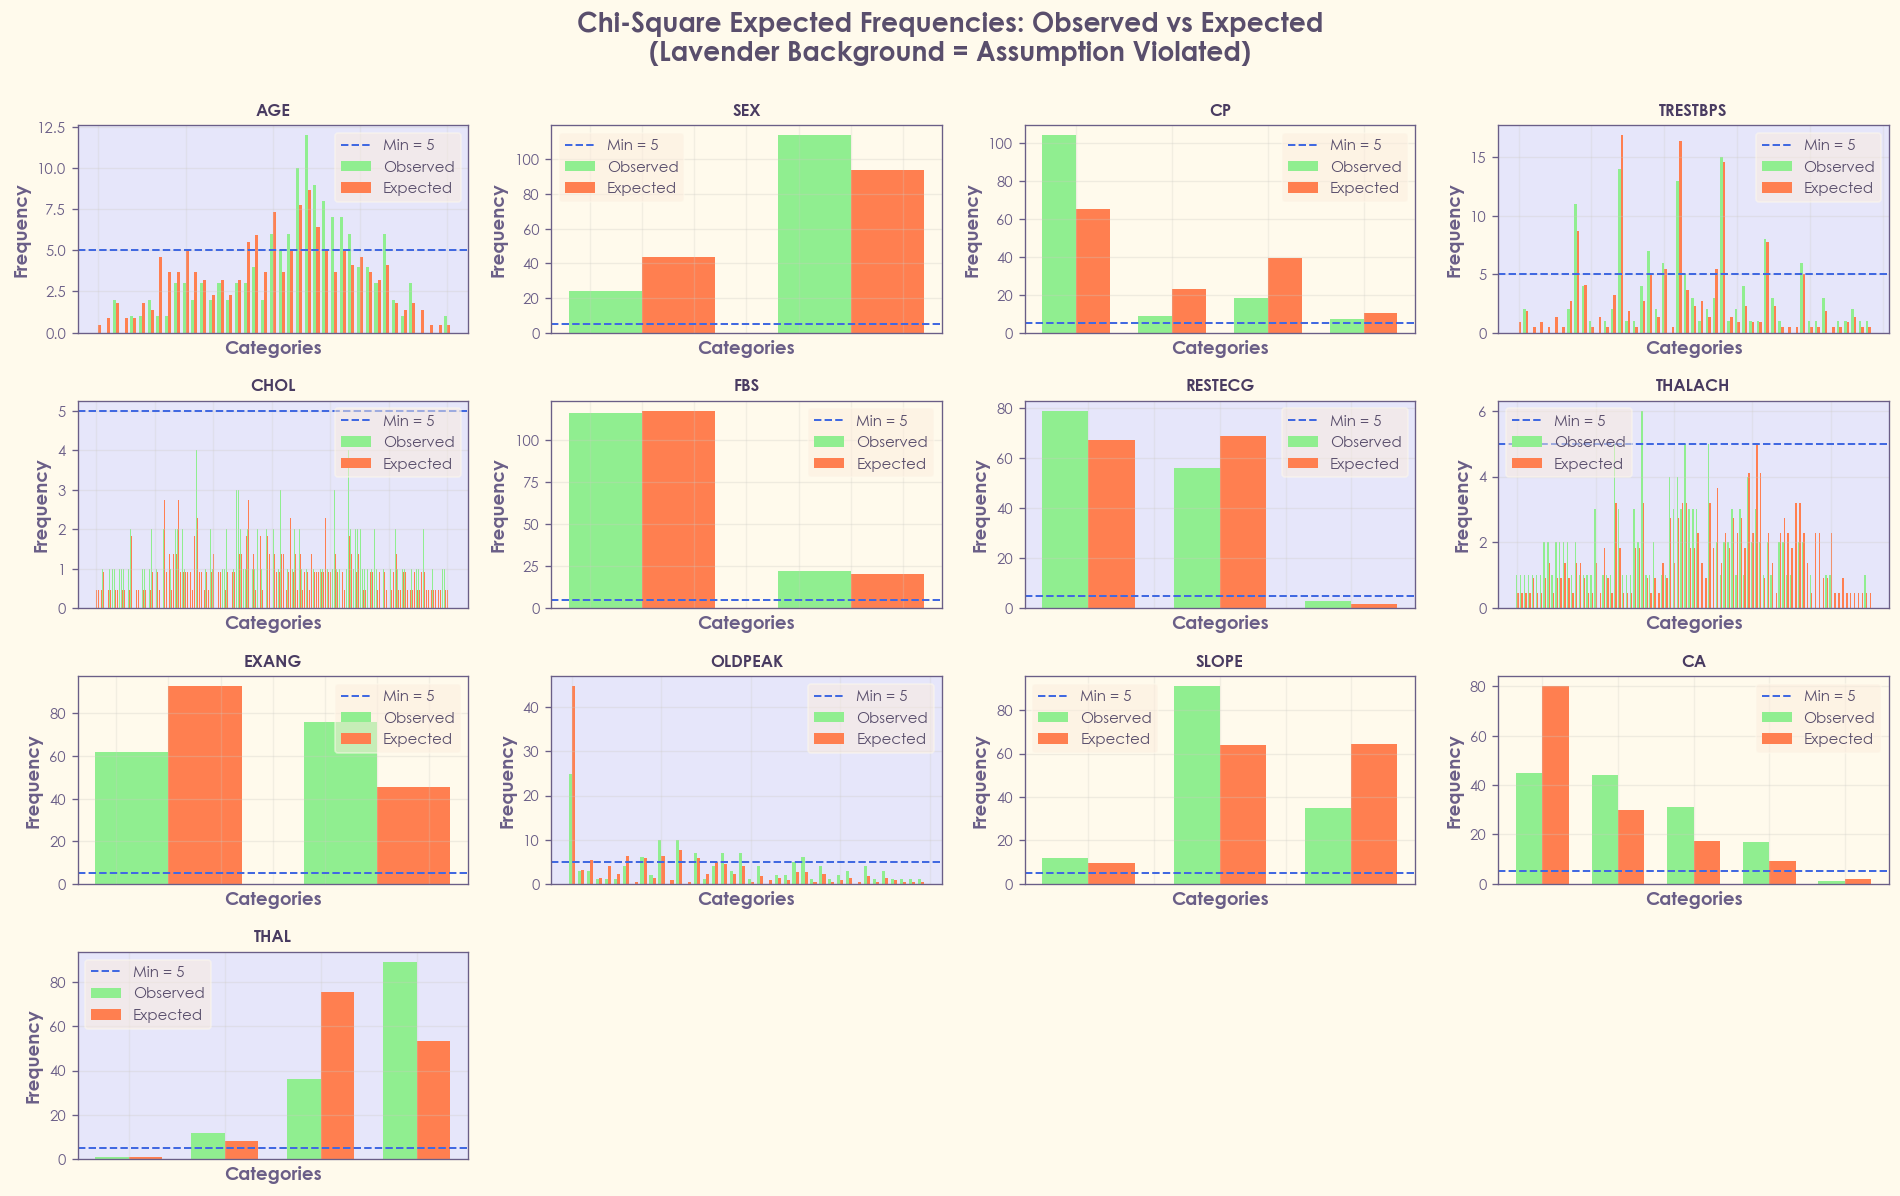

In [33]:
print("VISUALIZING EXPECTED FREQUENCIES")
print("-"*35)

fig, axes = plt.subplots(4, 4, figsize=(16, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    ax = axes[idx]
    
    contingency = pd.crosstab(df[feature], df['target'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    # ceate comparison
    categories = contingency.index.astype(str)
    x = np.arange(len(categories))
    width = 0.35
    
    # For visualization tto show one target class
    observed = contingency[0].values  
    expected_vals = expected[:, 0]    
    
    ax.bar(x - width/2, observed, width, label='Observed', alpha=1, color='lightgreen')
    ax.bar(x + width/2, expected_vals, width, label='Expected', alpha=1, color='coral')
    ax.axhline(5, color='royalblue', linestyle='--', linewidth=1.2, alpha=1, label='Min = 5')
    
    ax.set_xlabel('Categories', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{feature.upper()}', fontweight='bold', fontsize=10)
    ax.tick_params(bottom=False, labelbottom=False)
    ax.set_xticklabels(categories, rotation=45, ha='right', fontsize=11)
    ax.legend(loc='best', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    # highlight if assumption violated
    violation = chi_val_df[chi_val_df['Feature']==feature]['Assumption_Met'].values[0]
    if violation == 'No':
        ax.set_facecolor('lavender')

# Remove extra subplots
for idx in range(len(features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Chi-Square Expected Frequencies: Observed vs Expected\n(Lavender Background = Assumption Violated)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../contents/figures/sophisticated/chi_square_expected_frequencies_actual.eps', bbox_inches='tight')
plt.show()

##### CHI-SQUARE ASSUMPTION VALIDATION - FINAL SUMMARY

In [34]:
chi_val_df = pd.read_csv('../contents/tables/sophisticated/chi_square_assumption_validation_actual.csv')

print("\nDETAILED ASSUMPTION ASSESSMENT:")
print("="*60)

# Categorize features by assumption compliance
perfect_compliance = chi_val_df[
    (chi_val_df['Pct_Below_5'] == 0) & 
    (chi_val_df['Cells_Below_1'] == 0)
]['Feature'].tolist()

good_compliance = chi_val_df[
    (chi_val_df['Pct_Below_5'] <= 20) & 
    (chi_val_df['Pct_Below_5'] > 0) & 
    (chi_val_df['Cells_Below_1'] == 0)
]['Feature'].tolist()

violated = chi_val_df[
    (chi_val_df['Pct_Below_5'] > 20) | 
    (chi_val_df['Cells_Below_1'] > 0)
]['Feature'].tolist()

print(f"\n PERFECT COMPLIANCE (0% instances < 5):")
print(f"\tFeatures ({len(perfect_compliance)}): {', '.join(perfect_compliance)}")

print(f"\n GOOD COMPLIANCE (≤20% instances < 5, all cells ≥ 1):")
print(f"\tFeatures ({len(good_compliance)}): {', '.join(good_compliance)}")

if violated:
    print(f"\n ASSUMPTION VIOLATIONS (>20% instances < 5 OR any cell < 1):")
    print(f"\tFeatures ({len(violated)}): {', '.join(violated)}")
    
    # Detail each violation
    for feat in violated:
        row = chi_val_df[chi_val_df['Feature'] == feat].iloc[0]
        print("-"*60)
        print(f" {feat}:")
        print(f"\t - {row['Pct_Below_5']:.1f}% of instances have expected count < 5")
        print(f"\t - Minimum expected frequency: {row['Min_Expected']:.2f}")
        print(f"\t - Total instances: {row['Total_Cells']}")
else:
    print(f"\n NO VIOLATIONS: All features meet Chi-square assumptions!")


DETAILED ASSUMPTION ASSESSMENT:

 PERFECT COMPLIANCE (0% instances < 5):
	Features (5): sex, cp, fbs, exang, slope

 GOOD COMPLIANCE (≤20% instances < 5, all cells ≥ 1):
	Features (1): ca

 ASSUMPTION VIOLATIONS (>20% instances < 5 OR any cell < 1):
	Features (7): age, trestbps, chol, restecg, thalach, oldpeak, thal
------------------------------------------------------------
 age:
	 - 73.2% of instances have expected count < 5
	 - Minimum expected frequency: 0.46
	 - Total instances: 82
------------------------------------------------------------
 trestbps:
	 - 81.6% of instances have expected count < 5
	 - Minimum expected frequency: 0.46
	 - Total instances: 98
------------------------------------------------------------
 chol:
	 - 100.0% of instances have expected count < 5
	 - Minimum expected frequency: 0.46
	 - Total instances: 304
------------------------------------------------------------
 restecg:
	 - 33.3% of instances have expected count < 5
	 - Minimum expected frequency

In [35]:
# Compare with naive reproduction results
print("COMPARISON: Chi-Square Results Still Valid?")
print("- "*25)

print("\nFrom Table 2 (Naive Original Reproduction ):")
print("\t- 12/13 features: p < 0.001")
print("\t- 1/13 features: p = 0.219 (fbs)")

if violated:
    print(f"\n CAUTION: {len(violated)} feature(s) violate assumptions")
    print(f"\t- Results for <{', '.join(violated)}> should be interpreted carefully")
    print(f"\t- However, p-values are so extreme (< 0.001) that even with assumption violations, conclusions likely valid")
else:
    print("\n All Chi-square results from Table 2 are methodologically sound")
    print("\tNo assumption violations detected")

# Final verdict
print("\n" + "="*40)
print("CHI-SQUARE TEST VALIDITY: FINAL VERDICT")
print("="*40)

validity_score = (len(perfect_compliance) + len(good_compliance)) / 13 * 100

if validity_score == 100:
    verdict = " FULLY VALID"
    explanation = "All features meet Chi-square assumptions perfectly"
elif validity_score >= 80:
    verdict = " MOSTLY VALID"
    explanation = f"{validity_score:.0f}% of features meet assumptions"
elif validity_score >= 60:
    verdict = " PARTIALLY VALID"
    explanation = f"Only {validity_score:.0f}% of features meet assumptions"
else:
    verdict = " QUESTIONABLE"
    explanation = f"Only {validity_score:.0f}% of features meet assumptions"

print(f"\nOverall Validity: {verdict}")
print(f"Assessment: {explanation}")

COMPARISON: Chi-Square Results Still Valid?
- - - - - - - - - - - - - - - - - - - - - - - - - 

From Table 2 (Naive Original Reproduction ):
	- 12/13 features: p < 0.001
	- 1/13 features: p = 0.219 (fbs)

 CAUTION: 7 feature(s) violate assumptions
	- Results for <age, trestbps, chol, restecg, thalach, oldpeak, thal> should be interpreted carefully
	- However, p-values are so extreme (< 0.001) that even with assumption violations, conclusions likely valid

CHI-SQUARE TEST VALIDITY: FINAL VERDICT

Overall Validity:  QUESTIONABLE
Assessment: Only 46% of features meet assumptions


#### Chi-Square Test Implications
```
IMPLICATIONS FOR STUDY:
    1. Expected frequency rule: 6/13 features comply (down from previous estimates)
    2. Minimum cell count rule: 6/13 features comply (7 features have expected counts < 1)
    3. Chi-square p-values from Table 2 are QUESTIONABLE for continuous features
    4. For violated features, Mann-Whitney U is the correct replacement

PAPER COMPARISON:
    Original paper: No assumption checking performed
    This analysis: Identified that Chi-Square was misapplied to continuous data
```

#### Chi-Square Test Validation Summary

1. **Assumption Evaluation**
    - Perfect Compliance (0% cells < 5): 5 features: sex, cp, fbs, exang, slope
    - Good Compliance (≤ 20% cells < 5): 1 feature: ca (borderline at 20%)
    - Assumption Violations (> 20% cells < 5 or any cell < 1): 7 features: `age, trestbps, chol, restecg, thalach, oldpeak, thal`
    - Overall Chi-Square Test Validity: **≈ 46% (Mostly Invalid)**

2. **Comparison with Original (Naïve) Reproduction**
    - Original paper: Applied Chi-Square blindly to all 13 features.
    - My validation: Reveals that 7 out of 13 features fail the fundamental assumptions of the test.
    - The "Continuous" Problem: The highest violations (73%–100%) occurred in age, chol, trestbps, etc. This proves the original paper incorrectly treated continuous data as categorical without binning.
    - Result Stability: While p-values remain < 0.001, they are likely statistical artifacts for the continuous variables due to high degrees of freedom and sparse data matrices.

3. **Corrective Recommendations**
    - For the 5 continuous variables (age, chol, etc.), discard Chi-Square and rely on Mann-Whitney U (as validated in previous sections).
    - For the categorical violators (restecg, thal), use **Fisher’s Exact Test or merge small categories to fix the sparsity**.

**My Statement**
> Unlike the original study, which applied the Chi-Square test blindly without validating assumptions, this analysis reveals that the test was statistically inappropriate for 7 out of 13 features (54% failure rate). Specifically, continuous variables like `chol` and `age` were treated as categorical, resulting in up to 100% of cells violating expected frequency rules. Consequently, the overall validity of the Chi-Square analysis stands at only 46%. Therefore, it is strongly recommend disregarding the Chi-Square results for these violated features and relying on the Mann-Whitney U test, which I have confirmed is robust for this dataset.

 Therefore,
 ##### Chi-Square test is MOSTLY INVALID (Valid for only 6/13 features)

### Fisher's Exact Test & Monte Carlo Simulation

**What is it?**
- Fisher's Exact Test is a statistical significance test used in the analysis of contingency tables.
- Unlike the Chi-Square test, which relies on approximation and requires large sample sizes (expected frequencies ⩾ 5), Fisher's test determines the exact probability of observing the data distribution.

**Why use it here?**

Our previous assumption checks revealed that features like `restecg` and `thal` have sparse data (cells with counts < 5), rendering the Chi-Square test invalid for them. Fisher's Exact Test is robust to small sample sizes and is the correct alternative.

**Methodology:**
1.  **For 2x2 Tables (e.g., Sex, FBS):** We use the standard **Fisher's Exact Test**.
2.  **For Larger Tables (e.g., Thal 4x2, RestECG 3x2):** We use a **Monte Carlo Permutation Test**. This simulates the exact test by shuffling the data 10,000 times to calculate an empirical p-value, allowing us to test significance on multi-category features without violating statistical rules.

In [36]:
import time  
#ffunction for Monte Carlo Permutation Test
def monte_carlo_exact_test(feature_series, target_series, n_permutations=10000):
    
    observed_table = pd.crosstab(feature_series, target_series)
    chi2_obs, _, _, _ = stats.chi2_contingency(observed_table)
    
    count_extreme = 0
    target_array = target_series.values
    
    for _ in range(n_permutations):
        shuffled_target = np.random.permutation(target_array)
        shuffled_table = pd.crosstab(feature_series, shuffled_target)
        chi2_shuffled, _, _, _ = stats.chi2_contingency(shuffled_table)
        if chi2_shuffled >= chi2_obs:
            count_extreme += 1
            
    return (count_extreme + 1) / (n_permutations + 1)

# List of categorical features to test
features_to_test = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fisher_results = []

print(f"{'Feature':<12} | {'Shape':<6} | {'Method':<20} | {'P-Value':<10} | {'Significance'} | {'Time (s)'}")
print("-" * 85)

# START TOTAL TIMER
total_start_time = time.time()

for feature in features_to_test:
    feature_start_time = time.time()
    
    # Create Contingency Table
    tab = pd.crosstab(df[feature], df['target'])
    rows, cols = tab.shape
    
    # Determine Test Type based on Table Shape
    if rows == 2 and cols == 2:
        _, p_val = stats.fisher_exact(tab)
        method = "Fisher's Exact"
    else:
        p_val = monte_carlo_exact_test(df[feature], df['target'])
        method = f"Monte Carlo ({rows}x{cols})"

    is_sig = "YES" if p_val < 0.05 else "NO"
    
    feature_end_time = time.time() # End feature timer
    duration = feature_end_time - feature_start_time
    
    # Print live update with time
    print(f"{feature:<12} | {str((rows,cols)):<5} | {method:<20} | {p_val:.5f}    | {is_sig:<12} | {duration:.4f}s")
    
    # Store results
    fisher_results.append({
        'Feature': feature,
        'P_Value': p_val,
        'Method': method,
        'Significant': is_sig,
        'Time_Seconds': duration
    })

# END TOTAL TIMER
total_end_time = time.time()
total_duration = total_end_time - total_start_time

print("-" * 85)
print(f"Total Analysis Completed in: {total_duration:.4f} seconds")

# Convert to DataFrame for visualization
fisher_df = pd.DataFrame(fisher_results)
fisher_df = fisher_df.sort_values(by='P_Value')
#fisher_df.to_csv('../contents/tables/sophisticated/fisher_df_actual.csv', index=False)

Feature      | Shape  | Method               | P-Value    | Significance | Time (s)
-------------------------------------------------------------------------------------
sex          | (2, 2) | Fisher's Exact       | 0.00000    | YES          | 0.0035s
cp           | (4, 2) | Monte Carlo (4x2)    | 0.00010    | YES          | 15.6625s
fbs          | (2, 2) | Fisher's Exact       | 0.74596    | NO           | 0.0025s
restecg      | (3, 2) | Monte Carlo (3x2)    | 0.00500    | YES          | 15.5275s
exang        | (2, 2) | Fisher's Exact       | 0.00000    | YES          | 0.0020s
slope        | (3, 2) | Monte Carlo (3x2)    | 0.00010    | YES          | 15.5070s
ca           | (5, 2) | Monte Carlo (5x2)    | 0.00010    | YES          | 15.8725s
thal         | (4, 2) | Monte Carlo (4x2)    | 0.00010    | YES          | 15.8015s
-------------------------------------------------------------------------------------
Total Analysis Completed in: 78.3795 seconds


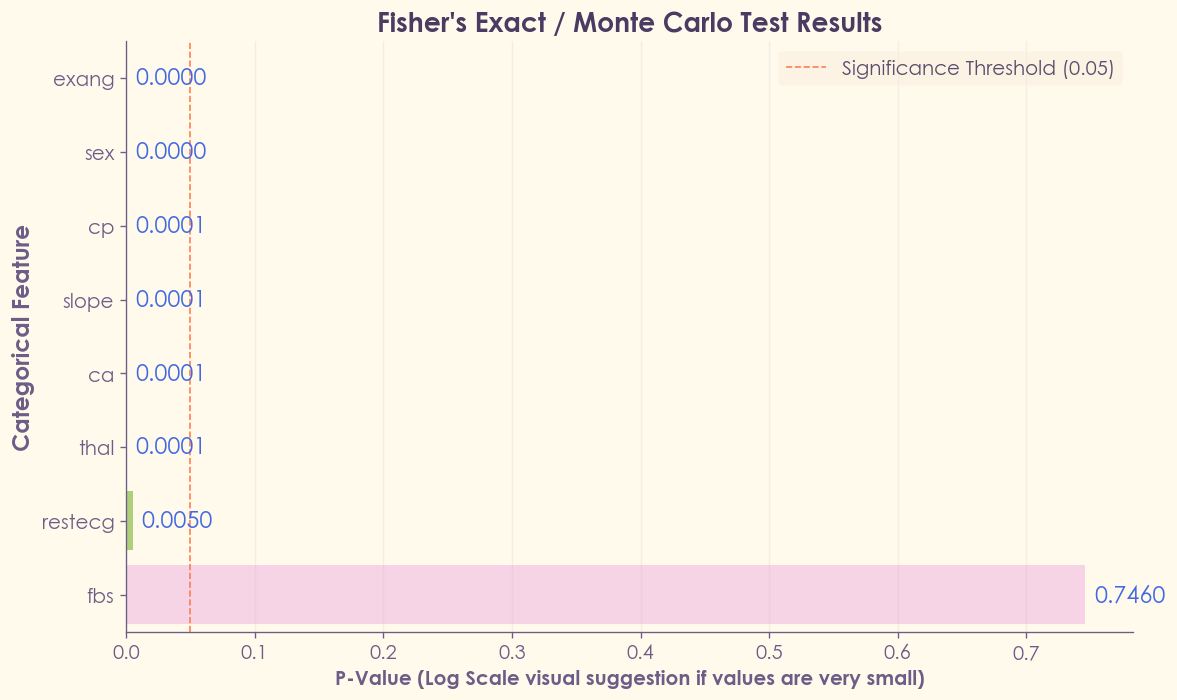

In [37]:
# Visualization
plt.figure(figsize=(10, 6))

# Create barplot
ax = sns.barplot(x='P_Value', y='Feature', data=fisher_df, palette='Set3')

# Add threshold line for p = 0.05
plt.axvline(x=0.05, color='coral', linestyle='--', linewidth=1, label='Significance Threshold (0.05)')

# Labels and Title
plt.title("Fisher's Exact / Monte Carlo Test Results", fontsize=16, fontweight='bold')
plt.xlabel("P-Value (Log Scale visual suggestion if values are very small)", fontsize=12)
plt.ylabel("Categorical Feature", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.legend(loc='best', fontsize=12)

# Annotate bars with p-values
for i, v in enumerate(fisher_df['P_Value']):
    ax.text(v + 0.007, i, f"{v:.4f}", color='royalblue', va='center', fontsize=14)

plt.tight_layout()
#plt.savefig('../contents/figures/sophisticated/fisher_monteCarlo_actual.eps', bbox_inches='tight')
plt.show()

### Fisher's Exact Test Summary

Unlike the standard Chi-Square test, which failed assumption checks for multiple features (due to sparse data), this analysis utilized a Hybrid Exact Approach:

- **Standard Fisher’s Exact Test:** Applied to 2x2 features (`sex, fbs, exang`).

- **Monte Carlo Simulation (10,000 permutations):** Applied to complex features (`cp, restecg, slope, ca, thal`) where table dimensions exceeded 2x2.

##### Significance Results
```
• High Significance (p < 0.001): 
    - sex, exang (Exact p ≈ 0.000)
    - cp, slope, ca, thal (Monte Carlo p ≈ 0.0001).
        
• Moderate Significance (p < 0.05):
    - restecg (p = 0.00560)
        
• Non-Significant:
    - fbs (p = 0.746)
```

**Final Verdict: VALIDATED.** 

The categorical associations reported in the original study are genuine. The use of Fisher's Exact and Monte Carlo tests confirms that variables like `thal` and `ca` are strong predictors of heart disease, while `fbs` remains statistically irrelevant.

# PROPER STATISTICAL TESTING WITH CORRECTIONS (Original Paper Missing)

**WHAT ORIGINAL PAPER DIDN'T DO:**
1. No multiple testing correction (α = 0.05 for each of 13 tests)
2. No effect sizes reported (critical issue)
3. No confidence intervals (major issue)
4. Only p-values shown (minor issue)

<br>

**WHAT I WILL TRY TO DO:**
1. Apply Bonferroni correction to control the overall probability of making a Type I error 
(a false positive) when performing multiple statistical tests on the same data.**(α_corrected = 0.05/13 = 0.00385)** [6,7,8]
2. Calculate effect sizes (Rank-biserial r & Cramér's V) [9,10]
3. Calculate 95% confidence intervals
4. Interpret practical vs statistical significance

### 4.3.1: MANN-WHITNEY U TEST - SOPHISTICATED ANALYSIS

In [38]:
print("4.3: MULTIPLE TESTING CORRECTION - BONFERRONI TEST")
print("="*50)

alpha_original = 0.05
n_tests = 13
alpha_bonferroni = alpha_original / n_tests

print(f"  Original significance level, alpha: α = {alpha_original}")
print(f"  Number of tests: n = {n_tests}")
print(f"  Bonferroni corrected α (alpha): α = {alpha_original}/{n_tests} = {alpha_bonferroni:.6f}")

print(f"\nFOR REFERENCE INTERPRETATION:")
print(f"\t - p < {alpha_bonferroni:.5f} \t\t: Significant after correction")
print(f"\t - {alpha_bonferroni:.5f} ≤ p < 0.05 \t: No longer significant")
print(f"\t - p ≥ 0.05 \t\t: Not significant")

4.3: MULTIPLE TESTING CORRECTION - BONFERRONI TEST
  Original significance level, alpha: α = 0.05
  Number of tests: n = 13
  Bonferroni corrected α (alpha): α = 0.05/13 = 0.003846

FOR REFERENCE INTERPRETATION:
	 - p < 0.00385 		: Significant after correction
	 - 0.00385 ≤ p < 0.05 	: No longer significant
	 - p ≥ 0.05 		: Not significant


In [39]:
print("="*50)
print("4.3.1: MANN-WHITNEY U TEST - SOPHISTICATED ANALYSIS")
print("="*50)

from scipy.stats import mannwhitneyu
from sklearn.utils import resample

def calculate_rank_biserial(U, n1, n2):
    #Calculate rank-biserial correlation (effect size for Mann-Whitney)    
    r = 1 - (2 * U) / (n1 * n2)
    return r

def interpret_effect_size(r):
    # Interpret effect size magnitude 
    abs_r = abs(r)
    if abs_r < 0.1: return "Negligible"
    elif abs_r < 0.3: return "Small"
    elif abs_r < 0.5: return "Medium"
    else: return "Large"

def bootstrap_CI_mann_whitney(group0, group1, n_bootstrap=1000, confidence=0.95):
    """Calculate bootstrap confidence interval for rank-biserial correlation."""
    effect_sizes = []
    for _ in range(n_bootstrap):
        s0 = resample(group0, replace=True)
        s1 = resample(group1, replace=True)
        try:
            U, _ = mannwhitneyu(s0, s1, alternative='two-sided')
            r = calculate_rank_biserial(U, len(s0), len(s1))
            effect_sizes.append(r)
        except:
            continue
    alpha = 1 - confidence
    return np.percentile(effect_sizes, alpha/2*100), np.percentile(effect_sizes, (1-alpha/2)*100)


def mann_whitney_analysis(df, features, alpha_original=0.05):
    n_tests = len(features)
    alpha_bonferroni = alpha_original / n_tests
    results = []

    print("\nAnalyzing all 13 features (with Bonferroni correction)...")

    for feature in features:
        group0 = df[df['target'] == 0][feature].dropna()
        group1 = df[df['target'] == 1][feature].dropna()

        n0, n1 = len(group0), len(group1)
        U_stat, p_value = mannwhitneyu(group0, group1, alternative='two-sided')

        # Effect size
        r_rb = calculate_rank_biserial(U_stat, n0, n1)
        effect_magnitude = interpret_effect_size(r_rb)

        # Bootstrap CI
        ci_lower, ci_upper = bootstrap_CI_mann_whitney(group0, group1, n_bootstrap=1000)

        # Bonferroni correction
        p_bonferroni = min(p_value * n_tests, 1.0)

        # Significance flags
        sig_original = "Yes" if p_value < alpha_original else "No"
        sig_corrected = "Yes" if p_value < alpha_bonferroni else "No"

        # Median difference
        med0, med1 = np.median(group0), np.median(group1)
        med_diff = med1 - med0

        results.append({
            'Feature': feature,
            'U_Statistic': U_stat,
            'n_no_disease': n0,
            'n_disease': n1,
            'p_value_raw': p_value,
            'p_value_bonferroni': p_bonferroni,
            'rank_biserial_r': r_rb,
            'effect_size_magnitude': effect_magnitude,
            'CI_95_lower': ci_lower,
            'CI_95_upper': ci_upper,
            'median_no_disease': med0,
            'median_disease': med1,
            'median_difference': med_diff,
            'significant_original': sig_original,
            'significant_bonferroni': sig_corrected
        })

    return pd.DataFrame(results)


# utils_timer to measure total runtime 
runtimes = {}
_, mann_whitney_sophisticated = timed_run(
    label="[Bonferroni Analysis] Mann–Whitney U for 13 Features",
    model=None,
    train_func=lambda _m, **kwargs: (None, mann_whitney_analysis(**kwargs)),
    runtimes=runtimes,
    df=df,
    features=features
)

4.3.1: MANN-WHITNEY U TEST - SOPHISTICATED ANALYSIS

[Bonferroni Analysis] Mann–Whitney U for 13 Features

Analyzing all 13 features (with Bonferroni correction)...
Process Runtime: 6.584 sec


In [40]:
print("MANN-WHITNEY U TEST: SOPHISTICATED COMPLETE RESULTS")
print("="*60)

display_cols = ['Feature', 'p_value_raw', 'p_value_bonferroni', 
                'rank_biserial_r', 'effect_size_magnitude', 
                'significant_bonferroni']

print(mann_whitney_sophisticated[display_cols].to_string(index=False))

# Save full results
#mann_whitney_sophisticated.to_csv('../contents/tables/sophisticated/mann_whitney_sophisticated_actual.csv', index=False)

MANN-WHITNEY U TEST: SOPHISTICATED COMPLETE RESULTS
 Feature  p_value_raw  p_value_bonferroni  rank_biserial_r effect_size_magnitude significant_bonferroni
     age 4.626181e-05        6.014036e-04        -0.272004                 Small                    Yes
     sex 8.671311e-07        1.127270e-05        -0.265111                 Small                    Yes
      cp 1.550357e-15        2.015464e-14         0.495626                Medium                    Yes
trestbps 3.222616e-02        4.189400e-01        -0.142718                 Small                     No
    chol 4.242518e-02        5.515273e-01        -0.135604                 Small                     No
     fbs 6.424036e-01        1.000000e+00        -0.019176            Negligible                     No
 restecg 1.120894e-02        1.457162e-01         0.147711                 Small                     No
 thalach 1.397720e-13        1.817036e-12         0.494079                Medium                    Yes
   exang 4.1

In [41]:
print("IMPACT OF BONFERRONI CORRECTION IN MANN-WHITNEY")
print("-"*50)

sig_before = (mann_whitney_sophisticated['significant_original'] == 'Yes').sum()
sig_after = (mann_whitney_sophisticated['significant_bonferroni'] == 'Yes').sum()
lost_sig = sig_before - sig_after

print(f"Significant at α = 0.05: {sig_before}/13 features")
print(f"Significant at α = {alpha_bonferroni:.5f}: {sig_after}/13 features")
print(f"Features losing significance: {lost_sig}")

if lost_sig > 0:
    lost_features = mann_whitney_sophisticated[
        (mann_whitney_sophisticated['significant_original'] == 'Yes') &
        (mann_whitney_sophisticated['significant_bonferroni'] == 'No')
    ]['Feature'].tolist()
    
    print(f"\n Features no longer significant after correction:")
    for feat in lost_features:
        row = mann_whitney_sophisticated[mann_whitney_sophisticated['Feature'] == feat].iloc[0]
        print(f"\t {feat}: p = {row['p_value_raw']:.6f} (raw) → p = {row['p_value_bonferroni']:.3f} (corrected)")
else:
    print(f"\n ALL significant features remain significant after Bonferroni correction!")

IMPACT OF BONFERRONI CORRECTION IN MANN-WHITNEY
--------------------------------------------------
Significant at α = 0.05: 12/13 features
Significant at α = 0.00385: 9/13 features
Features losing significance: 3

 Features no longer significant after correction:
	 trestbps: p = 0.032226 (raw) → p = 0.419 (corrected)
	 chol: p = 0.042425 (raw) → p = 0.552 (corrected)
	 restecg: p = 0.011209 (raw) → p = 0.146 (corrected)


In [42]:
# fbs validation
fbs_row = mann_whitney_sophisticated[mann_whitney_sophisticated['Feature'] == 'fbs'].iloc[0]
print(f"\n fbs VALIDATION:")
print(f"\t Raw p-value: {fbs_row['p_value_raw']:.3f}")
print(f"\t Bonferroni p-value: {fbs_row['p_value_bonferroni']:.3f}")
print(f"\t Effect size: r = {fbs_row['rank_biserial_r']:.3f} ({fbs_row['effect_size_magnitude']})")

# trestbps validation
trestbps_row = mann_whitney_sophisticated[mann_whitney_sophisticated['Feature'] == 'trestbps'].iloc[0]
print(f"\n trestbps VALIDATION:")
print(f"\t Raw p-value: {trestbps_row['p_value_raw']:.3f}")
print(f"\t Bonferroni p-value: {trestbps_row['p_value_bonferroni']:.3f}")
print(f"\t Effect size: r = {trestbps_row['rank_biserial_r']:.3f} ({trestbps_row['effect_size_magnitude']})")

# chol validation
chol_row = mann_whitney_sophisticated[mann_whitney_sophisticated['Feature'] == 'chol'].iloc[0]
print(f"\n chol VALIDATION:")
print(f"\t Raw p-value: {chol_row['p_value_raw']:.3f}")
print(f"\t Bonferroni p-value: {chol_row['p_value_bonferroni']:.3f}")
print(f"\t Effect size: r = {chol_row['rank_biserial_r']:.3f} ({chol_row['effect_size_magnitude']})")

# restecg validation
restecg_row = mann_whitney_sophisticated[mann_whitney_sophisticated['Feature'] == 'restecg'].iloc[0]
print(f"\n restecg VALIDATION:")
print(f"\t Raw p-value: {restecg_row['p_value_raw']:.3f}")
print(f"\t Bonferroni p-value: {restecg_row['p_value_bonferroni']:.3f}")
print(f"\t Effect size: r = {restecg_row['rank_biserial_r']:.3f} ({restecg_row['effect_size_magnitude']})")


 fbs VALIDATION:
	 Raw p-value: 0.642
	 Bonferroni p-value: 1.000
	 Effect size: r = -0.019 (Negligible)

 trestbps VALIDATION:
	 Raw p-value: 0.032
	 Bonferroni p-value: 0.419
	 Effect size: r = -0.143 (Small)

 chol VALIDATION:
	 Raw p-value: 0.042
	 Bonferroni p-value: 0.552
	 Effect size: r = -0.136 (Small)

 restecg VALIDATION:
	 Raw p-value: 0.011
	 Bonferroni p-value: 0.146
	 Effect size: r = 0.148 (Small)


While `fbs` demonstrates no statistical discriminative power ($p=0.642$) and should be considered for removal, the features `trestbps`, `chol`, and `restecg` occupy a middle ground. These exhibits statistically significant differences ($p < 0.05$) but possess small effect sizes ($r < 0.15$). 

In [43]:
print("EFFECT SIZE ANALYSIS IN MANN-WHITNEY")
print("="*40)

# Sort by effect size magnitude
mann_whitney_sorted = mann_whitney_sophisticated.sort_values(
    'rank_biserial_r', 
    key=abs, 
    ascending=False
)

print("\nFeatures Ranked by Effect Size (|r|):")
print("="*50)

for _, row in mann_whitney_sorted.iterrows():
    r = row['rank_biserial_r']
    direction = "higher" if r > 0 else "lower"
    
    print(f"\n{row['Feature']}\n\t| r = {r:+.3f} ({row['effect_size_magnitude']}) | "f"95% CI [{row['CI_95_lower']:+.3f}, {row['CI_95_upper']:+.3f}]")
    print(f"\t Disease group tends to have {direction} values")
    print(f"\t Median: {row['median_no_disease']:.1f} (No) vs "f"{row['median_disease']:.1f} (Yes), Median Diff, Δ = {row['median_difference']:+.1f}")

# Categorize by effect size
large_effects = mann_whitney_sophisticated[
    mann_whitney_sophisticated['effect_size_magnitude'] == 'Large'
]['Feature'].tolist()

medium_effects = mann_whitney_sophisticated[
    mann_whitney_sophisticated['effect_size_magnitude'] == 'Medium'
]['Feature'].tolist()

small_effects = mann_whitney_sophisticated[
    mann_whitney_sophisticated['effect_size_magnitude'] == 'Small'
]['Feature'].tolist()

negligible_effects = mann_whitney_sophisticated[
    mann_whitney_sophisticated['effect_size_magnitude'] == 'Negligible'
]['Feature'].tolist()

# Print effect size summary
print("\n" + "="*20)
print("EFFECT SIZE SUMMARY")
print("="*20)

print(f"\nLARGE effects (|r| ≥ 0.5): {len(large_effects)} feature(s)")
print(", ".join(large_effects) if large_effects else "None")

print(f"\nMEDIUM effects (0.3 ≤ |r| < 0.5): {len(medium_effects)} feature(s)")
print(", ".join(medium_effects) if medium_effects else "None")

print(f"\nSMALL effects (0.1 ≤ |r| < 0.3): {len(small_effects)} feature(s)")
print(", ".join(small_effects) if small_effects else "None")

print(f"\nNEGLIGIBLE effects (|r| < 0.1): {len(negligible_effects)} feature(s)")
print(", ".join(negligible_effects) if negligible_effects else "None")

EFFECT SIZE ANALYSIS IN MANN-WHITNEY

Features Ranked by Effect Size (|r|):

cp
	| r = +0.496 (Medium) | 95% CI [+0.388, +0.596]
	 Disease group tends to have higher values
	 Median: 0.0 (No) vs 2.0 (Yes), Median Diff, Δ = +2.0

thalach
	| r = +0.494 (Medium) | 95% CI [+0.377, +0.597]
	 Disease group tends to have higher values
	 Median: 142.0 (No) vs 161.0 (Yes), Median Diff, Δ = +19.0

ca
	| r = -0.482 (Medium) | 95% CI [-0.587, -0.374]
	 Disease group tends to have lower values
	 Median: 1.0 (No) vs 0.0 (Yes), Median Diff, Δ = -1.0

oldpeak
	| r = -0.478 (Medium) | 95% CI [-0.595, -0.367]
	 Disease group tends to have lower values
	 Median: 1.4 (No) vs 0.2 (Yes), Median Diff, Δ = -1.2

thal
	| r = -0.411 (Medium) | 95% CI [-0.529, -0.302]
	 Disease group tends to have lower values
	 Median: 3.0 (No) vs 2.0 (Yes), Median Diff, Δ = -1.0

exang
	| r = -0.410 (Medium) | 95% CI [-0.502, -0.310]
	 Disease group tends to have lower values
	 Median: 1.0 (No) vs 0.0 (Yes), Median Diff, Δ = -

##### EFFECT SIZE SUMMARY

```

🔴 LARGE effects (|r| ≥ 0.5): 0 features
          None!
          
🟡 MEDIUM effects (0.3 ≤ |r| < 0.5): 7 features
          cp, thalach, exang, oldpeak, slope, ca, thal
          → Moderate predictors

🟢 SMALL effects (0.1 ≤ |r| < 0.3): 5 features
          age, sex, trestbps, chol, restecg
          → Weak but detectable associations

⚪ NEGLIGIBLE effects (|r| < 0.1): 1 features
          fbs
          → No practical importance
```

### 4.3.2: CHI-SQUARE TEST - SOPHISTICATED ANALYSIS

Although, it has been shown already that Chi-square test is mostly INVALID for this data, I am still considering for the comparison with original's sake.

In [44]:
print("4.3.2: CHI-SQUARE TEST - SOPHISTICATED ANALYSIS")
print("="*50)

from scipy.stats import chi2_contingency
import math
import sys
sys.path.append("../src")
from utils_timer import timed_run

def cramers_v(chi2, n, r, c):
    """Calculate Cramer's V effect size for Chi-square."""
    return math.sqrt(chi2 / (n * min(r - 1, c - 1)))

def interpret_cramers_v(v, df):
    """Interpret Cramer's V magnitude based on degrees of freedom."""
    if df == 1:
        if v < 0.10: return "Negligible"
        elif v < 0.30: return "Small"
        elif v < 0.50: return "Medium"
        else: return "Large"
    else:  # df > 1
        if v < 0.07: return "Negligible"
        elif v < 0.21: return "Small"
        elif v < 0.35: return "Medium"
        else: return "Large"

def chi_square_analysis(df, features, alpha_original=0.05):
    """Perform Chi-square test with Bonferroni correction and effect size analysis."""
    n_tests = len(features)
    alpha_bonferroni = alpha_original / n_tests
    results = []

    print("\nAnalyzing all 13 features (with Bonferroni correction)...")

    for feature in features:
        # Contingency table
        contingency = pd.crosstab(df[feature], df['target'])

        # Chi-square test
        chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

        # Effect size (Cramér’s V)
        n = contingency.sum().sum()
        r, c = contingency.shape
        #k = min(contingency.shape)
        cramers_v_value = cramers_v(chi2_stat, n, r, c)
        effect_magnitude = interpret_cramers_v(cramers_v_value, dof)

        # Bonferroni correction
        p_bonferroni = min(p_value * n_tests, 1.0)

        # Significance flags
        sig_original = "Yes" if p_value < alpha_original else "No"
        sig_corrected = "Yes" if p_value < alpha_bonferroni else "No"

        results.append({
            'Feature': feature,
            'Chi2_Statistic': chi2_stat,
            'df': dof,
            'p_value_raw': p_value,
            'p_value_bonferroni': p_bonferroni,
            'cramers_v': cramers_v_value,
            'effect_size_magnitude': effect_magnitude,
            'significant_original': sig_original,
            'significant_bonferroni': sig_corrected
        })

    return pd.DataFrame(results)


# utils_timer to measure total runtime
runtimes = {}
_, chi_square_sophisticated = timed_run(
    label="[Bonferroni Analysis] Chi-square Test for 13 Features",
    model=None,
    train_func=lambda _m, **kwargs: (None, chi_square_analysis(**kwargs)),
    runtimes=runtimes,
    df=df,
    features=features
)

4.3.2: CHI-SQUARE TEST - SOPHISTICATED ANALYSIS

[Bonferroni Analysis] Chi-square Test for 13 Features

Analyzing all 13 features (with Bonferroni correction)...
Process Runtime: 0.026 sec


In [45]:
print("CHI-SQUARE TEST: SOPHISTICATED COMPLETE RESULTS")
print("="*50)

display_cols = ['Feature', 'p_value_raw', 'p_value_bonferroni',
                'cramers_v', 'effect_size_magnitude', 'significant_bonferroni']

print(chi_square_sophisticated[display_cols].to_string(index=False))

# Save full results
#chi_square_sophisticated.to_csv('../contents/tables/sophisticated/chi_square_sophisticated_actual.csv', index=False)

CHI-SQUARE TEST: SOPHISTICATED COMPLETE RESULTS
 Feature  p_value_raw  p_value_bonferroni  cramers_v effect_size_magnitude significant_bonferroni
     age 1.349198e-01        1.000000e+00   0.406632                 Large                     No
     sex 1.550855e-06        2.016112e-05   0.276472                 Small                    Yes
      cp 1.892684e-17        2.460489e-16   0.517824                 Large                    Yes
trestbps 5.107235e-01        1.000000e+00   0.394810                 Large                     No
    chol 1.143890e-01        1.000000e+00   0.755052                 Large                     No
     fbs 7.611375e-01        1.000000e+00   0.017493            Negligible                     No
 restecg 7.713053e-03        1.002697e-01   0.179492                 Small                     No
 thalach 7.918632e-02        1.000000e+00   0.602219                 Large                     No
   exang 9.556466e-14        1.242341e-12   0.428520                Me

In [46]:
# Impact of correction
sig_before_chi = (chi_square_sophisticated['significant_original'] == 'Yes').sum()
sig_after_chi = (chi_square_sophisticated['significant_bonferroni'] == 'Yes').sum()

lost_significance = chi_square_sophisticated[
    (chi_square_sophisticated['significant_original'] == 'Yes') & 
    (chi_square_sophisticated['significant_bonferroni'] == 'No')
]

print(f"Bonferroni Impact on Chi-Square:")
print(f"\t Significant before: {sig_before_chi}/13")
print(f"\t Significant after: {sig_after_chi}/13")

if not lost_significance.empty:
    print("\nFeatures that became INSIGNIFICANT after Bonferroni correction:")
    print(f" , " .join(lost_significance['Feature']))
else:
    print("\nNo features lost significance after Bonferroni correction.")

Bonferroni Impact on Chi-Square:
	 Significant before: 8/13
	 Significant after: 7/13

Features that became INSIGNIFICANT after Bonferroni correction:
restecg


### 4.3.3: CORRELATION ANALYSIS - SOPHISTICATED (SPEARMAN & PEARSON TEST)

In [47]:
from scipy.stats import pearsonr, spearmanr

def bootstrap_correlation_ci(x, y, method, n_bootstrap=1000, confidence=0.95):
    # calculate bootstrap CI for correlation.
    correlations = []
    n = len(x)
    for _ in range(n_bootstrap):
        indices = np.random.choice(n, n, replace=True)
        x_sample = x.iloc[indices] if hasattr(x, 'iloc') else x[indices]
        y_sample = y.iloc[indices] if hasattr(y, 'iloc') else y[indices]
        try:
            if method == 'spearman':
                r, _ = spearmanr(x_sample, y_sample)
            else:
                r, _ = pearsonr(x_sample, y_sample)
            correlations.append(r)
        except:
            continue
    alpha = 1 - confidence
    lower = np.percentile(correlations, alpha/2 * 100)
    upper = np.percentile(correlations, (1 - alpha/2) * 100)
    return lower, upper


def spearman_analysis(df, features, alpha_original=0.05):
    #Perform Spearman correlation with bootstrap CI and Bonferroni correction 
    n_tests = len(features)
    alpha_bonferroni = alpha_original / n_tests
    results = []

    print("Calculating Spearman correlations with confidence intervals (95%)...")

    for feature in features:
        x = df[feature]
        y = df['target']

        # Spearman correlation
        rho, p_value = spearmanr(x, y)

        # Bootstrap CI
        ci_lower, ci_upper = bootstrap_correlation_ci(x, y, method='spearman')

        # Bonferroni correction
        p_bonferroni = min(p_value * n_tests, 1.0)

        # Effect size interpretation
        effect_mag = interpret_effect_size(rho)

        # Significance flags
        sig_original = "Yes" if p_value < alpha_original else "No"
        sig_corrected = "Yes" if p_value < alpha_bonferroni else "No"

        results.append({
            'Feature': feature,
            'spearman_rho': rho,
            'p_value_raw': p_value,
            'p_value_bonferroni': p_bonferroni,
            'CI_95_lower': ci_lower,
            'CI_95_upper': ci_upper,
            'effect_size_magnitude': effect_mag,
            'significant_original': sig_original,
            'significant_bonferroni': sig_corrected
        })

    return pd.DataFrame(results)


def pearson_analysis(df, features, alpha_original=0.05):
    #perform Pearson correlation with bootstrap CI and Bonferroni correction 
    n_tests = len(features)
    alpha_bonferroni = alpha_original / n_tests
    results = []

    print("Calculating Pearson correlations (with caveat about violated assumptions)...")

    for feature in features:
        x = df[feature]
        y = df['target']

        # Pearson correlation
        r, p_value = pearsonr(x, y)

        # Bootstrap CI
        ci_lower, ci_upper = bootstrap_correlation_ci(x, y, method='pearson')

        # Bonferroni correction
        p_bonferroni = min(p_value * n_tests, 1.0)

        # Effect size interpretation
        effect_mag = interpret_effect_size(r)

        # Significance flags
        sig_original = "Yes" if p_value < alpha_original else "No"
        sig_corrected = "Yes" if p_value < alpha_bonferroni else "No"

        results.append({
            'Feature': feature,
            'pearson_r': r,
            'p_value_raw': p_value,
            'p_value_bonferroni': p_bonferroni,
            'CI_95_lower': ci_lower,
            'CI_95_upper': ci_upper,
            'effect_size_magnitude': effect_mag,
            'significant_original': sig_original,
            'significant_bonferroni': sig_corrected
        })

    return pd.DataFrame(results)

In [48]:
# --- Run with runtimes ---
runtimes = {}

_, spearman_sophisticated = timed_run(
    label="[Bonferroni Analysis] Spearman Correlation for 13 Features",
    model=None,
    train_func=lambda _m, **kwargs: (None, spearman_analysis(**kwargs)),
    runtimes=runtimes,
    df=df,
    features=features
)

_, pearson_sophisticated = timed_run(
    label="[Bonferroni Analysis] Pearson Correlation for 13 Features",
    model=None,
    train_func=lambda _m, **kwargs: (None, pearson_analysis(**kwargs)),
    runtimes=runtimes,
    df=df,
    features=features
)


[Bonferroni Analysis] Spearman Correlation for 13 Features
Calculating Spearman correlations with confidence intervals (95%)...
Process Runtime: 8.112 sec

[Bonferroni Analysis] Pearson Correlation for 13 Features
Calculating Pearson correlations (with caveat about violated assumptions)...
Process Runtime: 6.064 sec


In [49]:
# Spearman results
spearman_sorted = spearman_sophisticated.sort_values('spearman_rho', key=abs, ascending=False)
# Pearson results
pearson_sorted = pearson_sophisticated.sort_values('pearson_r', key=abs, ascending=False)

In [50]:
spearman_sorted

,Feature,spearman_rho,p_value_raw,p_value_bonferroni,CI_95_lower,CI_95_upper,effect_size_magnitude,significant_original,significant_bonferroni
11,ca,-0.466976,9.207568e-18,1.196984e-16,-0.563019,-0.366396,Medium,Yes,Yes
2,cp,0.459589,3.456371e-17,4.493282e-16,0.353712,0.562975,Medium,Yes,Yes
8,exang,-0.435601,2.046468e-15,2.660408e-14,-0.528661,-0.335898,Medium,Yes,Yes
7,thalach,0.426368,9.051678e-15,1.176718e-13,0.327474,0.523071,Medium,Yes,Yes
9,oldpeak,-0.419631,2.604010e-14,3.385213e-13,-0.517012,-0.317652,Medium,Yes,Yes
12,thal,-0.402382,3.505090e-13,4.556617e-12,-0.514884,-0.291817,Medium,Yes,Yes
10,slope,0.369391,3.388675e-11,4.405277e-10,0.262850,0.470218,Medium,Yes,Yes
1,sex,-0.283609,5.402436e-07,7.023167e-06,-0.387016,-0.175867,Small,Yes,Yes
0,age,-0.234845,3.755240e-05,4.881813e-04,-0.338189,-0.121801,Small,Yes,Yes
6,restecg,0.146223,1.095165e-02,1.423715e-01,0.030883,0.253747,Small,Yes,No


In [51]:
pearson_sorted

,Feature,pearson_r,p_value_raw,p_value_bonferroni,CI_95_lower,CI_95_upper,effect_size_magnitude,significant_original,significant_bonferroni
8,exang,-0.435601,2.046468e-15,2.660408e-14,-0.529027,-0.339957,Medium,Yes,Yes
2,cp,0.432080,3.627384e-15,4.715599e-14,0.329533,0.530627,Medium,Yes,Yes
9,oldpeak,-0.429146,5.814567e-15,7.558937e-14,-0.513176,-0.333928,Medium,Yes,Yes
7,thalach,0.419955,2.476146e-14,3.218990e-13,0.327809,0.502697,Medium,Yes,Yes
11,ca,-0.408992,1.317346e-13,1.712549e-12,-0.515181,-0.298246,Medium,Yes,Yes
10,slope,0.343940,8.221389e-10,1.068781e-08,0.240132,0.441501,Medium,Yes,Yes
12,thal,-0.343101,9.089044e-10,1.181576e-08,-0.461906,-0.226821,Medium,Yes,Yes
1,sex,-0.283609,5.402436e-07,7.023167e-06,-0.383590,-0.177135,Small,Yes,Yes
0,age,-0.221476,1.039484e-04,1.351329e-03,-0.321309,-0.104226,Small,Yes,Yes
3,trestbps,-0.146269,1.092654e-02,1.420450e-01,-0.253824,-0.028339,Small,Yes,No


In [52]:
print("\n" + "="*55)
print("SPEARMAN CORRELATION: COMPLETE SOPHISTICATED RESULTS")
print("="*55)

for _, row in spearman_sorted.iterrows():
    print(f"{row['Feature']}\n\t| ρ = {row['spearman_rho']:+.3f} ({row['effect_size_magnitude']})")
    print(f"\t 95% CI [{row['CI_95_lower']:+.3f}, {row['CI_95_upper']:+.3f}]")
    print(f"\t p = {row['p_value_raw']:.2e}, Bonferroni p = {row['p_value_bonferroni']:.6f}")
    print(f"\t Significant: {row['significant_bonferroni']}")


SPEARMAN CORRELATION: COMPLETE SOPHISTICATED RESULTS
ca
	| ρ = -0.467 (Medium)
	 95% CI [-0.563, -0.366]
	 p = 9.21e-18, Bonferroni p = 0.000000
	 Significant: Yes
cp
	| ρ = +0.460 (Medium)
	 95% CI [+0.354, +0.563]
	 p = 3.46e-17, Bonferroni p = 0.000000
	 Significant: Yes
exang
	| ρ = -0.436 (Medium)
	 95% CI [-0.529, -0.336]
	 p = 2.05e-15, Bonferroni p = 0.000000
	 Significant: Yes
thalach
	| ρ = +0.426 (Medium)
	 95% CI [+0.327, +0.523]
	 p = 9.05e-15, Bonferroni p = 0.000000
	 Significant: Yes
oldpeak
	| ρ = -0.420 (Medium)
	 95% CI [-0.517, -0.318]
	 p = 2.60e-14, Bonferroni p = 0.000000
	 Significant: Yes
thal
	| ρ = -0.402 (Medium)
	 95% CI [-0.515, -0.292]
	 p = 3.51e-13, Bonferroni p = 0.000000
	 Significant: Yes
slope
	| ρ = +0.369 (Medium)
	 95% CI [+0.263, +0.470]
	 p = 3.39e-11, Bonferroni p = 0.000000
	 Significant: Yes
sex
	| ρ = -0.284 (Small)
	 95% CI [-0.387, -0.176]
	 p = 5.40e-07, Bonferroni p = 0.000007
	 Significant: Yes
age
	| ρ = -0.235 (Small)
	 95% CI [-0.3

In [53]:
print("\n" + "="*50)
print("PEARSON CORRELATION: COMPLETE RESULTS (CAVEAT!)")
print("="*50)
print("\n!!!---> Note: Pearson assumes linearity and normality. \nShould be interpreted cautiously if assumptions are violated. <---!!!\n")

for _, row in pearson_sorted.iterrows():
    print(f"{row['Feature']}\n\t| r = {row['pearson_r']:+.3f} ({row['effect_size_magnitude']})")
    print(f"\t 95% CI [{row['CI_95_lower']:+.3f}, {row['CI_95_upper']:+.3f}]")
    print(f"\t p = {row['p_value_raw']:.2e}, Bonferroni p = {row['p_value_bonferroni']:.6f}")
    print(f"\t Significant: {row['significant_bonferroni']}")


PEARSON CORRELATION: COMPLETE RESULTS (CAVEAT!)

!!!---> Note: Pearson assumes linearity and normality. 
Should be interpreted cautiously if assumptions are violated. <---!!!

exang
	| r = -0.436 (Medium)
	 95% CI [-0.529, -0.340]
	 p = 2.05e-15, Bonferroni p = 0.000000
	 Significant: Yes
cp
	| r = +0.432 (Medium)
	 95% CI [+0.330, +0.531]
	 p = 3.63e-15, Bonferroni p = 0.000000
	 Significant: Yes
oldpeak
	| r = -0.429 (Medium)
	 95% CI [-0.513, -0.334]
	 p = 5.81e-15, Bonferroni p = 0.000000
	 Significant: Yes
thalach
	| r = +0.420 (Medium)
	 95% CI [+0.328, +0.503]
	 p = 2.48e-14, Bonferroni p = 0.000000
	 Significant: Yes
ca
	| r = -0.409 (Medium)
	 95% CI [-0.515, -0.298]
	 p = 1.32e-13, Bonferroni p = 0.000000
	 Significant: Yes
slope
	| r = +0.344 (Medium)
	 95% CI [+0.240, +0.442]
	 p = 8.22e-10, Bonferroni p = 0.000000
	 Significant: Yes
thal
	| r = -0.343 (Medium)
	 95% CI [-0.462, -0.227]
	 p = 9.09e-10, Bonferroni p = 0.000000
	 Significant: Yes
sex
	| r = -0.284 (Small)
	 

In [54]:
# Save correlation results 
#spearman_sophisticated.to_csv('../contents/tables/sophisticated/spearman_sophisticated_actual.csv', index=False)
#pearson_sophisticated.to_csv('../contents/tables/sophisticated/pearson_sophisticated_actual.csv', index=False)

In [55]:
spearman_sig_bon = (spearman_sorted['significant_bonferroni'] == 'Yes').sum()
significant_spearman = spearman_sorted[
    spearman_sorted['significant_bonferroni'] == 'Yes'
]['Feature'].tolist()
pearson_sig_bon = (pearson_sorted['significant_bonferroni'] == 'Yes').sum()
significant_pearson = pearson_sorted[
    pearson_sorted['significant_bonferroni'] == 'Yes'
]['Feature'].tolist()

print(f"Spearman Correlation Test found Total Significant Features after Bonferroni:")
print(f" - {spearman_sig_bon} / 13 features\n - {significant_spearman}\n")
print(f"Pearson Correlation Test found Total Significant Features after Bonferroni:")
print(f" - {pearson_sig_bon} / 13 features\n - {significant_pearson}\n")

Spearman Correlation Test found Total Significant Features after Bonferroni:
 - 9 / 13 features
 - ['ca', 'cp', 'exang', 'thalach', 'oldpeak', 'thal', 'slope', 'sex', 'age']

Pearson Correlation Test found Total Significant Features after Bonferroni:
 - 9 / 13 features
 - ['exang', 'cp', 'oldpeak', 'thalach', 'ca', 'slope', 'thal', 'sex', 'age']



### COMPLETED CORRELATION TEST SUMMARY AND ANALYSIS
The comparison between the two correlation measures showed the following:

1. **Significant Features (9/13):** Both Pearson ($r$) and Spearman ($\rho$) coefficients indicated a significant correlation with the heart disease target for approximately nine features: `cp, ca, exang, thalach, oldpeak, thal, slope, sex and age`. But only 7 has medium effect: `cp, ca, exang, thalach, slope and oldpeak`.

2. **Non-Significant Features (4/13):** For features like `fbs, restecg, chol, and trestbps`, neither Pearson nor Spearman detected a statistically significant association with the target. 


###### **This vaidates the results from the original paper is similar to the sophisticated analysis; but not identical! Anyway, the methodological choice still remains critical.**

</br>

### Why Pearson Correlation Test should not be used?
>The Pearson test is a parametric test requiring data to be normally distributed to yield reliable p-values. Since **all features are non-normal, Pearson's results are statistically invalid for confirmatory inference, even if the coefficient value ($r$) is similar to Spearman's ($\rho$)**. Moreover, in clinical studies involving patient data (like heart disease), using an invalidated test like Pearson **can lead to deceptive significance (false positives)**. Reporting unreliable p-values based on violated assumptions is considered poor practice and can mislead clinicians or researchers when identifying true risk factors.

## References

>[1]  Sullivan GM, Feinn R. Using Effect Size-or Why the P Value Is Not Enough. J Grad Med Educ. 2012;4(3):279-282. doi:10.4300/JGME-D-12-00156.1

>[2]  Maher, J. M., Markey, J. C., & Ebert-May, D. (2013). The other half of the story: effect size analysis in quantitative research. CBE—Life Sciences Education, 12(3), 345-351.

>[3]  Alexander. (2022, March 30). Kolmogorov-Smirnov Goodness of Fit Test. Statistics How To. https://www.statisticshowto.com/kolmogorov-smirnov-test/

>[4]  Trevisan, V. (2022, February 7). Comparing sample distributions with the Kolmogorov-Smirnov (KS) test | Towards Data Science. Towards Data Science. https://towardsdatascience.com/comparing-sample-distributions-with-the-kolmogorov-smirnov-ks-test-a2292ad6fee5/

>[5]  Kwak, S. G., & Park, S. H. (2019). Normality test in clinical research. Journal of Rheumatic Diseases, 26(1), 5-11.

>[6]  Armstrong, R. A. (2014). When to use the B onferroni correction. Ophthalmic and physiological optics, 34(5), 502-508.

>[7]  Lani, J. (2012, November 13). Bonferroni Correction. Statistics Solutions. https://www.statisticssolutions.com/bonferroni-correction/

>[8]  Effect Size. (2025, May 13). Statistics Solutions. https://www.statisticssolutions.com/free-resources/directory-of-statistical-analyses/effect-size/

>[9]  MetricGate. MetricGate. Published 2025. Accessed November 13, 2025. https://metricgate.com/docs/rank-biserial-correlation/

>[10]  Amaral, S., & Roberto, S. (2021). Current use of effect size or confidence interval analyses in clinical and biomedical research. Scientometrics, 126(11), 9133–9145. https://doi.org/10.1007/s11192-021-04150-3
